# Transcription Factor Project - Replogle et al. (2022) K562 Dataset Downstream Analysis
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J genome-wide Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs). Compare to the Replogle et al. (2022) K562 genome-wide Perturb-seq dataset to explore cell-type-specific transcriptional regulatory networks in hiPSCs vs. chronic myeloid leukemia cells.

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory network of hiPSCs and K562 cells?
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

***

# Import statements

Using psp_env virtual env

In [1]:
import sys
import os
psp_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if psp_root not in sys.path:
    sys.path.insert(0, psp_root)

import psp

In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import decoupler as dc
import gseapy as gp
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
from biothings_client import get_client

In [14]:
def validate_3_DGE_results_dfs(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Check that 3 DGE analysis results DFs have same rows and cols.
    """
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    DGE_results_1 = DGE_results_dfs[0].sort_index()
    DGE_results_2 = DGE_results_dfs[1].sort_index()
    DGE_results_3 = DGE_results_dfs[2].sort_index()
    if not (DGE_results_1.index.equals(DGE_results_2.index) and 
            DGE_results_2.index.equals(DGE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DGE_results_1.columns) == set(DGE_results_2.columns)) &
            (set(DGE_results_2.columns) == set(DGE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Return DFs with sorted index
    return [DGE_results_1, DGE_results_2, DGE_results_3]

def build_3_run_DEGs_dict(DGE_results_dfs: list[pd.DataFrame],
                          p_threshold: float,
                          p_threshold_type: str="pvalue",
                          target_type: str="gRNA",
                          lfc_threshold: float = 0,
                          lfc_col: str = "log2FoldChange",
                          validate: bool=True,
                          remove_self_DEGs: bool=True,
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that are DEGs of that KD (pass significance 
    and LFC thresholds) in at least 2 DGE analysis runs.
    If remove_self_DEGs is True, then Gene A is removed from the DEG list
    for Gene KD A and so on.
    """
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    # Check for valid target type
    if target_type not in ("gRNA", "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target'")
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DGE_results_1.columns}
    else:
        targets = {col.split("_")[0] for col in DGE_results_1.columns}
    targets = sorted(list(targets))
    DEGs_dict = dict()
    for target in targets:
        target_p_col = f"{target}_{p_threshold_type}"
        target_lfc_col = f"{target}_{lfc_col}"
        DEGs_run1 = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (abs(DGE_results_1[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run2 = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (abs(DGE_results_2[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run3 = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (abs(DGE_results_3[target_lfc_col]) > lfc_threshold)].index)                                 
        DEGs_at_least_2 = ((DEGs_run1 & DEGs_run2) | (DEGs_run2 & DEGs_run3) |
                           (DEGs_run1 & DEGs_run3))
        # Remove gene target from DEG list
        if remove_self_DEGs:
            self_gene = target if target_type == "gene_target" else target.split("_")[0]
            DEGs_at_least_2 = DEGs_at_least_2 - {self_gene}
        DEGs_dict[target] = DEGs_at_least_2
    return DEGs_dict

def build_3_run_wald_dict(DGE_results_dfs: list[pd.DataFrame],
                          wald_col: str="stat",
                          wald_abs_threshold: float = 1,
                          validate: bool = True,
                          kds: list[str] | set[str] | None = None,
                          remove_target_gene: bool=True,
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that have |Wald| > wald_abs_threshold 
    in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # For each KD, find genes with |Wald| > 1 in at least 2 runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if kds is None:
        kds = {col.split("_")[0] for col in DGE_results_1.columns}
    kds = sorted(list(kds))
    wald_dict = dict()
    for kd in kds:
        kd_wald_col = f"{kd}_{wald_col}"
        wald_genes_run1 = set(DGE_results_1.loc[
            abs(DGE_results_1[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run2 = set(DGE_results_2.loc[
            abs(DGE_results_2[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run3 = set(DGE_results_3.loc[
            abs(DGE_results_3[kd_wald_col]) > wald_abs_threshold].index)                                
        wald_genes_at_least_2 = ((wald_genes_run1 & wald_genes_run2) | 
                                 (wald_genes_run2 & wald_genes_run3) |
                                 (wald_genes_run1 & wald_genes_run3))
        # Remove target gene from gene list
        if remove_target_gene:
            wald_genes_at_least_2 = wald_genes_at_least_2 - {kd}
        wald_dict[kd] = wald_genes_at_least_2
    return wald_dict

def build_3_run_n_DEGs_df(DEGs_dict: dict[str, set[str]]
                          ) -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame reporting
    the number of DEGs per KD.
    """
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df.sort_values(by="n_DEGs", ascending=False)
    return n_DEGs_df

def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = sorted(list(cluster_DEGs_dict.keys()))
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in clusters]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10, rotation=90)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

# Read in data

In [4]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_norm_KDefficiency_Etest_gRNA_filtered.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 244096 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'chromium_batch', 'sequencing_lane', 'well_plate', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'target_detected', 'perturbation', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cel

In [5]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_dfs_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [6]:
kd_deg_dict_k562 = build_3_run_DEGs_dict(de_results_dfs_k562, p_threshold=0.005,
                                         p_threshold_type="pvalue", target_type="gene_target",
                                         remove_self_DEGs=True)

In [7]:
n_degs_df_k562 = build_3_run_n_DEGs_df(kd_deg_dict_k562)
n_degs_df_k562.head(25)

,n_DEGs
DNMT1,405
CXXC1,164
MAX,149
MYB,140
TFDP1,127
TBX1,119
ETV4,106
NKX6-1,103
SETDB1,93
ZBTB17,76


In [ ]:
n_degs_df_k562[49:50]

,n_DEGs
SP2,32


In [8]:
kd_subset = set(n_degs_df_k562[n_degs_df_k562['n_DEGs'] > 4].index)
print(f"{len(kd_subset)} out of {len(n_degs_df_k562)} TF KDs have >4 DEGs (excluding self-DEGs)")

429 out of 916 TF KDs have >4 DEGs (excluding self-DEGs)


In [11]:
kd_wald_dict_k562 = build_3_run_wald_dict(de_results_dfs_k562, kds=kd_subset, remove_target_gene=True)

In [13]:
leiden_clusters_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-4-26.csv"
leiden_clusters_k562 = pd.read_csv(leiden_clusters_filepath, header=0, index_col=0)
leiden_clusters_k562.head(3)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,ALX3,CTCFL,ARID3B,ADNP,ARID5B,ARID2,DLX4,ATF1,FOXI3,CHAMP1,...,AHRR,FOXO1,ETV4,AKAP8L,AEBP1,FIGLA,ERG,EVX2,CREBL2,CXXC4
1,BAZ2B,FEZF1,BATF,ADNP2,CPEB1,ATMIN,EMX1,DR1,IKZF1,FBXL19,...,HES4,HOXA9,HMBOX1,CARF,CLOCK,FOXL2,GMEB1,FOXG1,FLI1,DLX2
2,FOS,HEY1,CEBPB,BHLHE40,CXXC1,CAMTA2,FOXM1,DRAP1,KIN,FOXN1,...,HOXA10,IKZF4,MSANTD4,E2F8,RFX5,HIC2,HOXB6,IKZF2,MTF1,TBX18


In [15]:
cluster_deg_dict_k562 = build_cluster_DEGs_dict(kd_deg_dict_k562,
                                                leiden_clusters_k562)

In [16]:
sns.set_style("whitegrid")

2026-06-04 14:33:53 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-04 14:33:53 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


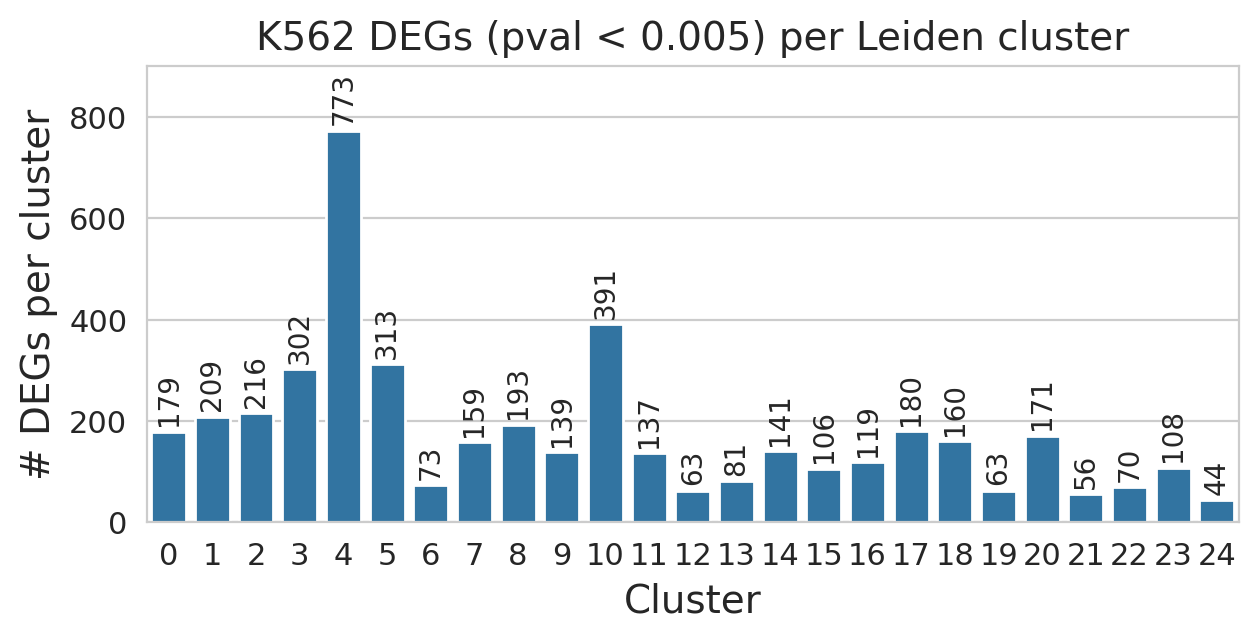

In [20]:
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_k562,
                            title="K562 DEGs (pval < 0.005) per Leiden cluster",
                            figsize=(7,3), ymax=900)

In [122]:
kd_deg_dict_k562_with_self_degs = build_3_run_DEGs_dict(de_results_dfs_k562, p_threshold=0.005,
                                         p_threshold_type="pvalue", target_type="gene_target",
                                         remove_self_DEGs=False)
n_degs_df_k562_with_self_degs = build_3_run_n_DEGs_df(kd_deg_dict_k562_with_self_degs)

In [129]:
strong_tf_kds = n_degs_df_k562_with_self_degs[n_degs_df_k562_with_self_degs["n_DEGs"] >= 10].index.tolist()
print(len(strong_tf_kds))
print(", ".join(strong_tf_kds[:10]))
strong_tf_kds = set(strong_tf_kds)

197
DNMT1, CXXC1, MAX, MYB, TFDP1, TBX1, ETV4, NKX6-1, SETDB1, ZBTB17


In [141]:
top_50_tf_kds = n_degs_df_k562_with_self_degs.head(50).index.tolist()
print(len(top_50_tf_kds))
print(f"{', '.join(top_50_tf_kds[:5])}... {', '.join(top_50_tf_kds[45:])}")
top_50_tf_kds = set(top_50_tf_kds)

50
DNMT1, CXXC1, MAX, MYB, TFDP1... MEF2A, ZNF236, ZNF143, CLOCK, SP2


In [143]:
n_degs_df_k562_with_self_degs[n_degs_df_k562_with_self_degs.index == "SP2"]

,n_DEGs
SP2,33


# Filter Entrez genes for Pathview (using DGE results)

In [ ]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_dfs_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [13]:
def filter_rename_entrez_genes(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Rename genes in DGE results DF by Entrez ID and remove genes
    without an Entrez ID.
    """
    # Check that DGE results DFs have same rows (genes)
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    if not ((set(DGE_results_dfs[0].index) == set(DGE_results_dfs[1].index)) &
            (set(DGE_results_dfs[1].index) == set(DGE_results_dfs[2].index))):
        raise ValueError("DGE results DataFrames must have same genes in index")

    # Query genes by symbol and Ensembl ID
    all_genes = DGE_results_dfs[0].index.tolist()
    mygene = get_client('gene')
    mg_results_df = mygene.querymany(all_genes, scopes="symbol,ensemblgene",
                                     field="entrezgene", species="human",
                                     entrezonly=True, as_dataframe=True)
    # Remove duplicates
    mg_results_df = mg_results_df.loc[~mg_results_df.index.duplicated(keep=False)]
    # First set of genes to rename
    found_mg_results_df = mg_results_df[mg_results_df["entrezgene"].notna()]
    gene_entrez_rename_dict1 = found_mg_results_df["entrezgene"].to_dict()

    # Query genes that were not found by alias
    genes_not_found = mg_results_df[mg_results_df["notfound"] == True].index.tolist()
    mg_alias_results_df = mygene.querymany(genes_not_found, scopes="alias", 
                                           field="entrezgene", species="human", 
                                           entrezonly=True, as_dataframe=True)
    # Remove duplicates
    mg_alias_results_df = \
        mg_alias_results_df.loc[~mg_alias_results_df.index.duplicated(keep=False)]
    # Second set of genes to rename
    found_mg_alias_results_df = mg_alias_results_df[mg_alias_results_df["entrezgene"].notna()]
    gene_entrez_rename_dict2 = found_mg_alias_results_df["entrezgene"].to_dict()

    # Rename genes
    gene_entrez_rename_dict = gene_entrez_rename_dict1 | gene_entrez_rename_dict2
    DGE_results_dfs_renamed = list()
    for DGE_df in DGE_results_dfs:
        DGE_df_renamed = DGE_df[DGE_df.index.isin(gene_entrez_rename_dict.keys())]
        DGE_df_renamed = DGE_df_renamed.rename(index=gene_entrez_rename_dict)
        DGE_results_dfs_renamed.append(DGE_df_renamed)
    return DGE_results_dfs_renamed

In [14]:
de_results_k562_1.shape

(8246, 5496)

In [15]:
de_results_entrez_k562 = \
    filter_rename_entrez_genes(de_results_dfs_k562)

2026-05-22 16:01:09 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-05-22 16:01:09 | [INFO] querying 1-1000 ...
2026-05-22 16:01:10 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:12 | [INFO] querying 1001-2000 ...
2026-05-22 16:01:13 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:14 | [INFO] querying 2001-3000 ...
2026-05-22 16:01:14 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:15 | [INFO] querying 3001-4000 ...
2026-05-22 16:01:16 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:17 | [INFO] querying 4001-5000 ...
2026-05-22 16:01:18 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:19 | [INFO] querying 5001-6000 ...
2026-05-22 16:01:20 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05

In [16]:
de_results_entrez_k562_1, de_results_entrez_k562_2, de_results_entrez_k562_3 = \
    de_results_entrez_k562[0], de_results_entrez_k562[1], de_results_entrez_k562[2]

In [17]:
de_results_entrez_k562_1.shape

(8122, 5496)

124 genes with no Entrez ID were removed

In [18]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26_entrez.pkl"
de_results_entrez_k562_1.to_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26_entrez.pkl"
de_results_entrez_k562_2.to_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26_entrez.pkl"
de_results_entrez_k562_3.to_pickle(filepath3)

In [19]:
kd_entrez_deg_dict_k562 = \
    build_3_run_DEGs_dict(de_results_entrez_k562, p_threshold=0.005,
                          p_threshold_type="pvalue", target_type="gene_target")

In [20]:
cluster_entrez_deg_dict = build_cluster_DEGs_dict(kd_entrez_deg_dict_k562,
                                                 leiden_clusters_k562)

In [22]:
sns.set_style("whitegrid")

2026-05-22 16:09:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-22 16:09:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


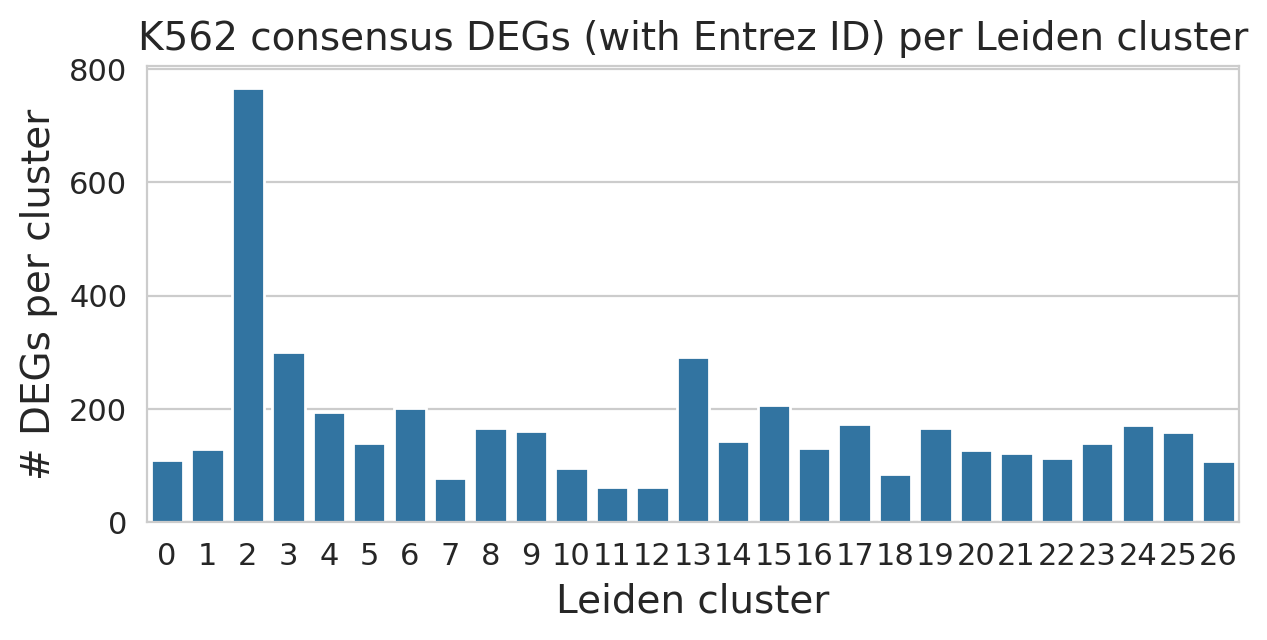

In [24]:
_ = plot_n_DEGs_per_cluster(cluster_entrez_deg_dict,
                            title="K562 consensus DEGs (with Entrez ID) per Leiden cluster",
                            figsize=(7,3), xlabel="Leiden cluster")

# Consensus LFC table for pathview/SBGNview

In [21]:
def build_consensus_lfc_dfs(
        DGE_results_dfs: list[pd.DataFrame],
        cluster_df: pd.DataFrame,
        p_threshold: float,
        p_threshold_type: str = "pvalue",
        lfc_col: str = "log2FoldChange",
        lfc_threshold: float = 0,
        remove_self_DEGs: bool=True
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build 2 DataFrames for pathway visualization, one 
    with consensus LFC values for each TF KD and one with 
    consensus LFC values for each cluster.

    If a gene is a DEG of a KD in at least 2 out of 3 DGE runs, it
    is a consensus DEG. For each KD, compute consensus LFC of each
    consensus DEG (take mean LFC of gene across any run where gene
    passes significance and LFC thresholds). Then for each cluster,
    for each gene, take mean of consensus LFCs across all cluster KDs.
    """
    # Check that DGE results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Build dict of KD: {consensus DEGs}
    DEGs_dict = build_3_run_DEGs_dict(DGE_results_dfs,
                                      p_threshold=p_threshold,
                                      p_threshold_type=p_threshold_type,
                                      target_type="gene_target",
                                      lfc_threshold=lfc_threshold,
                                      lfc_col=lfc_col,
                                      validate=False,
                                      remove_self_DEGs=remove_self_DEGs)
    
    # Get per-run LFC values
    kds = sorted(list(DEGs_dict.keys()))
    masked_run_lfc_dfs = list()
    for DGE_df in DGE_results_dfs:
        masked_lfc_cols = dict()
        for kd in kds:
            kd_p_col = DGE_df[f"{kd}_{p_threshold_type}"]
            kd_lfc_col = DGE_df[f"{kd}_{lfc_col}"].copy()
            # Get LFCs for genes that pass significance/LFC thresholds
            passes_run = (
                (kd_p_col < p_threshold) & (kd_lfc_col.abs() > lfc_threshold)
            ).fillna(False)
            # Set LFCs of genes that are not consensus DEGs to NaN
            in_consensus = kd_lfc_col.index.isin(DEGs_dict[kd])
            keep = passes_run.values & in_consensus
            kd_lfc_col[~keep] = np.nan
            # Add LFC col to dict
            masked_lfc_cols[kd] = kd_lfc_col
        # Add LFC cols for DGE run to list
        masked_run_lfc_df = pd.DataFrame(masked_lfc_cols, index=DGE_df.index)
        masked_run_lfc_dfs.append(masked_run_lfc_df)
    
    # Take mean LFCs across runs (skip NaNs)
    kd_consensus_lfc_df = pd.concat(masked_run_lfc_dfs).groupby(level=0).mean()

    # Build cluster LFC DF
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_lfc_cols = {}
    for cluster_num, cluster_kds in cluster_kd_dict.items():
        # Take mean LFC of each gene across cluster TF KDs
        cluster_lfc_cols[cluster_num] = \
            kd_consensus_lfc_df[cluster_kds].mean(axis=1).fillna(0)
    cluster_consensus_lfc_df = pd.DataFrame(cluster_lfc_cols, 
                                            index=kd_consensus_lfc_df.index)

    # Set NaN values to 0 in KD LFC DF
    kd_consensus_lfc_df = kd_consensus_lfc_df.fillna(0)
    
    return kd_consensus_lfc_df, cluster_consensus_lfc_df

In [22]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26_entrez.pkl"
de_results_entrez_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26_entrez.pkl"
de_results_entrez_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26_entrez.pkl"
de_results_entrez_k562_3 = pd.read_pickle(filepath3)
de_results_entrez_k562 = [de_results_entrez_k562_1, de_results_entrez_k562_2,
                          de_results_entrez_k562_3]

In [23]:
k562_kd_consensus_lfc_df, k562_cluster_consensus_lfc_df = \
    build_consensus_lfc_dfs(de_results_entrez_k562,
                            cluster_df=leiden_clusters_k562,
                            p_threshold=0.005, p_threshold_type="pvalue",
                            remove_self_DEGs=True)

In [24]:
k562_kd_consensus_lfc_df.head()

,ADNP,ADNP2,AEBP1,AEBP2,AHCTF1,AHRR,AIRE,AKAP8,AKAP8L,AKNA,...,ZNF92,ZNF98,ZSCAN12,ZSCAN18,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN30,ZSCAN5A,ZSCAN9
gene_name,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
k562_kd_consensus_lfc_df[["DNMT1"]].head()

,DNMT1
gene_name,
1,0.000000
100,-0.697518
10001,0.000000
10005,0.000000
10006,0.000000


In [26]:
filepath = "/home/ranwyl/output_files_tf_project/K562_KD_lfcs_pathview_6-4-26.csv"
k562_kd_consensus_lfc_df.to_csv(filepath)

In [27]:
k562_cluster_consensus_lfc_df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
gene_name,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,-0.697518,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10001,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10005,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10006,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
filepath = "/home/ranwyl/output_files_tf_project/K562_leiden_cluster_lfcs_pathview_6-4-26.csv"
k562_cluster_consensus_lfc_df.to_csv(filepath)

# TF-target dict

In [ ]:
def build_tf_target_dict_signed(source_list: list[str] = ["CollecTRI", "DoRothEA", 
                                                          "TF_Perturbations_Followed_by_Expression",
                                                          "TF-LOF_Expression_from_GEO"], 
                                tfs_to_rename_dict: dict[str, list] | None = None, 
                                dorothea_levels=["A", "B", "C"]) -> dict[str, dict[str, set[str]]]:
    """
    Build dict {TF: {"UP": set of upreg genes, "DOWN": set of downreg genes}}
    using decoupler and gseapy.
    """
    all_dicts = list()

    if "CollecTRI" in source_list:
        collectri_df = dc.op.collectri(organism='human')
        collectri_dict = dict()
        for tf, gene, weight in collectri_df.iloc[:,:3].itertuples(index=False, name=None):
            if tf not in collectri_dict:
                collectri_dict[tf] = {"UP":set(), "DOWN":set()}
            if weight > 0: # TF is activator --> gene is downregulated
                collectri_dict[tf]["DOWN"].add(gene)
            else: # TF is repressor --> gene is upregulated
                collectri_dict[tf]["UP"].add(gene)
        all_dicts.append(collectri_dict)
    
    if "DoRothEA" in source_list:
        dorothea_df = dc.op.dorothea(organism='human', levels=dorothea_levels)
        dorothea_dict = dict()
        for tf, gene, weight in dorothea_df.iloc[:,:3].itertuples(index=False, name=None):
            if tf not in dorothea_dict:
                dorothea_dict[tf] = {"UP":set(), "DOWN":set()}
            if weight > 0:
                dorothea_dict[tf]["DOWN"].add(gene)
            else:
                dorothea_dict[tf]["UP"].add(gene)
        all_dicts.append(dorothea_dict)

    # Perturbation and LOF Enrichr libraries
    ko_lof_lib_list = list()
    if "TF_Perturbations_Followed_by_Expression" in source_list:
        pert_lib = gp.get_library(name="TF_Perturbations_Followed_by_Expression")
        ko_lof_lib_list.append(pert_lib)
    if "TF-LOF_Expression_from_GEO" in source_list:
        lof_lib = gp.get_library("TF-LOF_Expression_from_GEO")
        ko_lof_lib_list.append(lof_lib)
    if ko_lof_lib_list:
        ko_lof_dict = dict()
        for lib in ko_lof_lib_list:
            for tf_label, genes in lib.items():
                tf_label = tf_label.upper()
                if "HUMAN" in tf_label:
                    tf_label = tf_label.split(" ")
                    tf, reg = tf_label[0], tf_label[-1]
                    if tf not in ko_lof_dict:
                        ko_lof_dict[tf] = {"UP":set(), "DOWN":set()}
                    if reg == "UP":
                        ko_lof_dict[tf]["UP"].update(set(genes))
                    elif reg == "DOWN":
                        ko_lof_dict[tf]["DOWN"].update(set(genes))
        if tfs_to_rename_dict:
            for old_name, new_name in tfs_to_rename_dict.items():
                if new_name == "":
                    ko_lof_dict.pop(old_name)
                else:
                    ko_lof_dict[new_name] = ko_lof_dict.pop(old_name)
        all_dicts.append(ko_lof_dict)

    # Combine
    if len(all_dicts) == 1:
        return all_dicts[0]
    all_tfs = {tf for target_dict in all_dicts for tf in target_dict.keys()}
    all_tf_targets_dict = {tf: {"UP": set(), "DOWN": set()} for tf in all_tfs}
    for tf in all_tfs:
        genes_up = {g for target_dict in all_dicts if tf in target_dict for g in target_dict[tf]["UP"]}
        genes_down = {g for target_dict in all_dicts if tf in target_dict for g in target_dict[tf]["DOWN"]}
        all_tf_targets_dict[tf]["UP"].update(genes_up)
        all_tf_targets_dict[tf]["DOWN"].update(genes_down)
    return all_tf_targets_dict

In [ ]:
import pickle

In [ ]:
tfs_rename_dict = {"NCOA":"", "RENT1":"UPF1", "HIF2A":"EPAS1"} # old name : new name
tf_target_interactions_dict = build_tf_target_dict_signed(
    ["CollecTRI", "DoRothEA", "TF_Perturbations_Followed_by_Expression", "TF-LOF_Expression_from_GEO"], 
    tfs_to_rename_dict=tfs_rename_dict)

2026-03-05 14:31:34 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-05 14:31:54 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-05 14:32:16 | [INFO] 0017 gene_sets have been filtered out when max_size=2000 and min_size=0


Save as pickle

In [ ]:
tf_target_dict_filepath = "/home/ranwyl/reference_tf_project/tf_target_signed_interactions.pkl"
with open(tf_target_dict_filepath, 'wb') as f: # binary write mode
    pickle.dump(tf_target_interactions_dict, f)

In [ ]:
# TF target dict

import pickle

tf_target_dict_filepath = "/home/ranwyl/reference_tf_project/tf_target_signed_interactions.pkl"
with open(tf_target_dict_filepath, 'rb') as f: # binary read mode
    tf_target_interactions_dict = pickle.load(f)

# Cluster-level GSEA

In [189]:
def prerank_gsea_cluster_kds(
        cluster_label: int | str,
        DGE_results_dfs: list[pd.DataFrame], 
        gene_set_lib: str,
        cluster_df: pd.DataFrame | None = None,
        cluster_kds: list[str] | None = None,
        drop_perturbed_gene: bool = True,
        rank_by: str="stat",
        min_term_size: int=5, 
        max_term_size: int=1000, 
        permutation_num: int=1000, 
        n_cpus_per_job: int=4,
        n_jobs: int=1,
        random_seed: int=42,
        verbose: bool=False,
        kd_col: str="KD",
        cluster_col: str="Cluster",
        gene_set_col: str="Gene set"
    ) -> pd.DataFrame:
    """
    Run pre-ranked GSEA using the given Enrichr library on each 
    individual KD in a cluster. For each KD, compute mean Wald test
    statistic of each gene across 3 DGE analysis runs and rank genes by
    mean Wald. min_size and max_size control Enrichr term size.
    """
    # Get list of KDs in cluster
    if not cluster_kds:
        if not cluster_df:
            raise ValueError("Cluster DF or cluster KD list must be provided")
        if isinstance(cluster_df.columns[0], str):
            cluster_kds = list(cluster_df[str(cluster_label)][
                cluster_df[str(cluster_label)].notna()])
        else:
            cluster_kds = list(cluster_df[int(cluster_label)][
                cluster_df[int(cluster_label)].notna()])
    
    # Helper function to run GSEA on single KD
    def process_kd(kd):
        rank_col = f"{kd}_{rank_by}"
        rank_df_1 = pd.DataFrame(DGE_results_dfs[0][rank_col].values,
                                 index=DGE_results_dfs[0].index, 
                                 columns=[rank_by])
        rank_df_2 = pd.DataFrame(DGE_results_dfs[1][rank_col].values,
                                 index=DGE_results_dfs[1].index, 
                                 columns=[rank_by])
        rank_df_3 = pd.DataFrame(DGE_results_dfs[2][rank_col].values,
                                 index=DGE_results_dfs[2].index, 
                                 columns=[rank_by])
        rank_df = (rank_df_1 + rank_df_2 + rank_df_3) / 3
        if drop_perturbed_gene:
            if kd in rank_df.index:
                rank_df.loc[kd] = np.nan
        rank_df.dropna(axis="index", inplace=True) # Drop NaN values
        rank_df.sort_values(by=rank_by, ascending=False, inplace=True)
        rank_df.index.name = "gene"
        # Run pre-ranked GSEA
        kd_prerank_result = \
            gp.prerank(rnk=rank_df,
                        gene_sets=gene_set_lib,
                        threads=n_cpus_per_job,
                        min_size=min_term_size,
                        max_size=max_term_size,
                        permutation_num=permutation_num,
                        outdir=None,
                        seed=random_seed,
                        verbose=verbose,
                        )
        return kd_prerank_result
    
    # Run GSEA on all KDs
    if n_jobs < 1:
        raise ValueError("Invalid value for n_jobs")
    if n_jobs == 1:
        kd_prerank_results_dict = dict()
        for kd in cluster_kds:
            kd_prerank_result = process_kd(kd)
            kd_prerank_results_dict[kd] = kd_prerank_result
    else: # Run in parallel
        with tqdm_joblib(desc="Running pre-ranked GSEA", 
                         total=len(cluster_kds)):
            kd_prerank_results = Parallel(n_jobs=n_jobs)(
                delayed(process_kd)(kd) for kd in cluster_kds)
        kd_prerank_results_dict = dict(zip(cluster_kds, kd_prerank_results))
    
    # Build results DF
    prerank_res_df_list = list()
    for kd in kd_prerank_results_dict:
        # Build results DF for KD
        kd_res_df = kd_prerank_results_dict[kd].res2d.copy()
        kd_res_df.insert(0, kd_col, [kd]*kd_res_df.shape[0])
        kd_res_df.drop(columns=["Name"], inplace=True)
        prerank_res_df_list.append(kd_res_df)
    # Build results DF for cluster
    cluster_prerank_res_df = pd.concat(prerank_res_df_list)
    cluster_prerank_res_df.insert(0, cluster_col, 
                                  [cluster_label]*cluster_prerank_res_df.shape[0])
    # Add gene set column
    cluster_prerank_res_df.insert(2, gene_set_col,
                                  [gene_set_lib]*cluster_prerank_res_df.shape[0])
    return cluster_prerank_res_df

def prerank_gsea_all_clusters(
        cluster_df: pd.DataFrame, 
        DGE_results_dfs: list[pd.DataFrame], 
        gene_set_lib: str,
        min_term_size: int=5, 
        max_term_size: int=1000, 
        permutation_num: int=1000, 
        n_cpus_per_cluster: int=4, 
        n_jobs_parallel: int=10,
        random_seed: int=42, 
        verbose: bool=False,
        rank_by: str = "stat",
        ) -> pd.DataFrame:
    """
    Run pre-ranked GSEA on all KDs using the given Enrichr library.
    For each KD, genes are ranked by mean Wald across 3 DGE analysis runs.
    Build a results DF where each term is labeled by KD and cluster.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Run GSEA
    cluster_kd_dict = {cl: list(cluster_df[cl][cluster_df[cl].notna()])
                       for cl in cluster_df.columns}   
    with tqdm_joblib(desc="Running pre-ranked GSEA", total=len(cluster_kd_dict)):
        cluster_prerank_results = Parallel(n_jobs=n_jobs_parallel)(
            delayed(prerank_gsea_cluster_kds)(
                    cluster_label=cluster,
                    cluster_kds=cluster_kd_dict[cluster], 
                    DGE_results_dfs=DGE_results_dfs, 
                    gene_set_lib=gene_set_lib, 
                    rank_by=rank_by,
                    min_term_size=min_term_size, 
                    max_term_size=max_term_size, 
                    permutation_num=permutation_num, 
                    n_cpus_per_job=n_cpus_per_cluster,
                    n_jobs=1,
                    random_seed=random_seed,
                    verbose=verbose)
                for cluster in cluster_kd_dict
            )
    prerank_results_df = pd.concat(cluster_prerank_results)
    return prerank_results_df

def build_enriched_gsea_terms_df(
        prerank_results_df: pd.DataFrame,
        DGE_results_dfs: list[pd.DataFrame],
        kd_col: str="KD",
        fdr_cutoff: float=0.05,
        fdr_col: str="FDR q-val",
        min_absolute_nes: None | float = None, 
        nes_col: str="NES",
        DGE_p_threshold: float = 0.05,
        DGE_p_threshold_type: str="pvalue",
        rank_by: str = "stat",
        rank_abs_threshold: int=1,
        leading_genes_col: str="Lead_genes",
        kd_DEG_dict: dict[str, set[str]] | None = None,
        kd_wald_dict: dict[str, set[str]] | None = None
    ) -> pd.DataFrame:
    """
    Subset the GSEA results DF to only enriched terms
    and add info on leading genes that are DEGs and
    that have |Wald| > 1 in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # Subset to enriched terms (by FDR and NES)
    prerank_results_df = \
        prerank_results_df[prerank_results_df[fdr_col] < fdr_cutoff]
    if min_absolute_nes:
        prerank_results_df = \
            prerank_results_df[prerank_results_df[nes_col] >= min_absolute_nes]
    enriched_results_df = prerank_results_df.copy()
    
    # Add info on leading genes that pass DE significance threshold
    #   and have |Wald| > threshold in at least 2 DGE runs
    # Build dict {KD: {DEGs}}
    kds = set(prerank_results_df[kd_col].values)
    if not kd_DEG_dict:
        kd_DEG_dict = build_3_run_DEGs_dict(DGE_results_dfs, 
                                            p_threshold=DGE_p_threshold,
                                            p_threshold_type=DGE_p_threshold_type,
                                            validate=False)
    kd_DEG_dict = {k:v for k,v in kd_DEG_dict.items() if k in kds}
    # Build dict {KD: {genes with |Wald| > threshold}}
    if not kd_wald_dict:
        kd_wald_dict = build_3_run_wald_dict(DGE_results_dfs, 
                                            wald_col=rank_by,
                                            wald_abs_threshold=rank_abs_threshold,
                                            validate=False)
    kd_wald_dict = {k:v for k,v in kd_wald_dict.items() if k in kds}
    
    # Get leading gene DE + Wald info
    kds_arr = enriched_results_df[kd_col].to_numpy()
    lead_genes_arr = enriched_results_df[leading_genes_col].to_numpy()
    n_de_leading, de_leading_str, n_wald_leading, wald_leading_str = [], [], [], []
    for kd, lead_genes in zip(kds_arr, lead_genes_arr):
        leading_genes = set(s for s in lead_genes.split(";") if s)
        de_leading = leading_genes & kd_DEG_dict.get(kd, set())
        wald_leading = leading_genes & kd_wald_dict.get(kd, set())
        n_de_leading.append(len(de_leading))
        de_leading_str.append(";".join(sorted(de_leading)))
        n_wald_leading.append(len(wald_leading))
        wald_leading_str.append(";".join(sorted(wald_leading)))
    
    # Add leading gene DE + Wald info to DF
    enriched_results_df.insert(10, "# DE lead genes", n_de_leading)
    enriched_results_df.insert(11, f"# lead genes w/ |Wald| > {rank_abs_threshold}", 
                               n_wald_leading)
    enriched_results_df["DE_lead_genes"] = de_leading_str
    enriched_results_df["Wald_lead_genes"] = wald_leading_str
    return enriched_results_df

def build_cluster_shared_gsea_terms_df(
        enriched_results_df: pd.DataFrame,
        gene_set_lib: str,
        min_cluster_kds: int=3,
        max_term_size: int=200,
        kd_col: str="KD",
        cluster_col: str="Cluster", 
        nes_col: str="NES",
        leading_genes_col: str="Lead_genes",
        DE_leading_genes_col: str="DE_lead_genes",
        rank_leading_genes_col: str="Wald_lead_genes",
        gene_set_col: str="Gene set",
        rank_abs_threshold: float = 1
        ) -> pd.DataFrame:
    """
    Given a pre-ranked GSEA results DF with enriched terms and
    info on genes that pass DE and |Wald| thresholds, find terms 
    shared between multiple cluster KDs.
    """
    cluster_results_dfs, summary_entries = list(), list()
    # Get Enrichr library
    enrichr_lib = gp.get_library(gene_set_lib, max_size=max_term_size)
    # Loop through clusters
    clusters = sorted(enriched_results_df[cluster_col].unique().tolist(), key=int)
    for cl in clusters:
        # Get cluster DF
        cl_df = enriched_results_df[enriched_results_df[cluster_col] == cl]
        if cl_df.empty:
            continue
        # Group cluster DF by term for fast lookup
        term_groups = dict(list(cl_df.groupby("Term", sort=False)))
        # Subset to shared terms
        term_counts = cl_df["Term"].value_counts()
        cl_shared_terms = set(term_counts[term_counts >= min_cluster_kds].index)
        cl_shared_direction_terms = set()
        for term in cl_shared_terms:
            # Get only shared terms with max size
            if enrichr_lib.get(term) is None:
                continue
            term_size = len(enrichr_lib[term])
            if term_size > max_term_size:
                continue
            # Get only shared terms where all TF KDs have same NES sign
            cl_term_df = term_groups[term]
            nes_values = cl_term_df[nes_col].to_numpy()
            if not (np.all(nes_values > 0) or np.all(nes_values < 0)):
                continue
            cl_shared_direction_terms.add(term)
            # Build summary entry and add to list
            term_kds = sorted(cl_term_df[kd_col].unique().tolist())
            term_lead_genes = \
                {g for genes in cl_term_df[leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_DE_lead_genes = \
                {g for genes in cl_term_df[DE_leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_rank_lead_genes = \
                {g for genes in cl_term_df[rank_leading_genes_col].values 
                 for g in genes.split(";") if g}
            rank_lead_genes_col = f"Total leading genes w/ |Wald| > {rank_abs_threshold}"
            summary_entries.append(
                {"Cluster": cl, "Term": term, 
                 f"# {kd_col}s": len(term_kds),
                 f"{kd_col}s": ", ".join(term_kds),
                 "Mean NES": round(cl_term_df[nes_col].mean(), 2),
                 "Term size": term_size,
                 "Total leading genes": len(term_lead_genes),
                 "Total DE leading genes": len(term_DE_lead_genes),
                 rank_lead_genes_col: len(term_rank_lead_genes)}
                 )
        # Add cluster shared terms DF to list
        cl_df = cl_df[cl_df["Term"].isin(cl_shared_direction_terms)]
        cl_df.sort_values(by=["Term", kd_col], inplace=True)
        cluster_results_dfs.append(cl_df)
    
    # If no enriched terms
    if len(cluster_results_dfs) == 0:
        return pd.DataFrame(), pd.DataFrame()
    
    # Build shared terms DF
    if len(cluster_results_dfs) > 1:
        shared_terms_df = pd.concat(cluster_results_dfs)
        shared_terms_df.reset_index(drop=True, inplace=True)
    else:
        shared_terms_df = cluster_results_dfs[0]
    # Build summary DF
    summary_df = pd.DataFrame(summary_entries)
    summary_df.insert(1, gene_set_col, [gene_set_lib]*summary_df.shape[0])
    summary_df.sort_values(by=["Mean NES", f"# {kd_col}s"], 
                           ascending=False, inplace=True)
    summary_df.reset_index(drop=True, inplace=True)

    return shared_terms_df, summary_df

In [157]:
ecc = gp.get_library("ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X", organism="Human", max_size=5000)

2026-06-04 16:36:02 | [INFO] Downloading and generating Enrichr library gene sets...


In [167]:
print(max([len(genes) for genes in ecc.values()]))

3715


## Cluster 0 (TAL1)

Contains hematopoietic TF KD TAL1 (50 DEGs)

In [32]:
cl0_tf_kds = list(leiden_clusters_k562["0"][leiden_clusters_k562["0"].notna()])
print(len(cl0_tf_kds))
print(", ".join(cl0_tf_kds))

34
ALX3, BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, IRF3, KCNIP3, KLF7, LHX8, MGA, MYPOP, MYRF, NKX1-2, OVOL2, PITX2, PLAGL2, PRDM8, PRR12, SCRT2, SGSM2, SHOX2, SPEN, STAT5A, TAL1, ZNF48, ZNF197, ZNF251, ZNF428, ZNF547, ZNF883, ZSCAN9


In [33]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl0_tf_kds)]

,n_DEGs
TAL1,49
PRDM8,29
STAT5A,26
SPEN,21
PLAGL2,14
HOXB5,12
FOXQ1,12
MYPOP,12
ZNF883,11
HOXC4,10


In [133]:
cl0_strong_tf_kds = strong_tf_kds & set(cl0_tf_kds)
print(f"{len(cl0_strong_tf_kds)} strong TF KDs in cluster: {', '.join(cl0_strong_tf_kds)}")

12 strong TF KDs in cluster: HOXC4, FOXQ1, MYPOP, PRDM8, SPEN, BAZ2B, STAT5A, ZNF883, HOXB5, PLAGL2, GLYR1, TAL1


In [144]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl0_strong_tf_kds)]

,n_DEGs
TAL1,49
PRDM8,29
STAT5A,26
SPEN,21
PLAGL2,14
HOXB5,12
FOXQ1,12
MYPOP,12
ZNF883,11
HOXC4,10


In [134]:
cl0_top_50_tf_kds = top_50_tf_kds & set(cl0_tf_kds)
print(f"{len(cl0_top_50_tf_kds)} top 50 TF KDs in cluster: {', '.join(cl0_top_50_tf_kds)}")

1 top 50 TF KDs in cluster: TAL1


### Hallmark

In [36]:
cl0_hallmark_results_full = prerank_gsea_cluster_kds(
    cluster_label=0,
    cluster_kds=cl0_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="MSigDB_Hallmark_2020",
    kd_col="TF KD")

In [37]:
cl0_hallmark_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,0,ALX3,MSigDB_Hallmark_2020,Myc Targets V1,-0.386462,-1.939772,0.0,0.002652,0.004,98/195,31.46%,CDK2;HSPE1;CDK4;C1QBP;NPM1;RPS6;FAM120A;HSPD1;...
1,0,ALX3,MSigDB_Hallmark_2020,Myc Targets V2,-0.447438,-1.809275,0.0,0.009283,0.027,20/56,16.76%,SLC19A1;HSPE1;TMEM97;CDK4;NPM1;SORD;IPO4;HSPD1...
2,0,ALX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.468341,1.761306,0.005405,0.058806,0.046,17/45,15.80%,JUN;TGFBR3;SAT1;LGALS1;WIPF1;TPM4;VEGFA;GADD45...


In [38]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl0_gsea_hallmark_6-4-26.pkl"
cl0_hallmark_results_full.to_pickle(hallmark_filepath)

In [39]:
cl0_hallmark_enriched = build_enriched_gsea_terms_df(
    cl0_hallmark_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1, 
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict = kd_wald_dict_k562
)

In [40]:
cl0_hallmark_shared_terms, cl0_hallmark_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl0_hallmark_enriched, gene_set_lib="MSigDB_Hallmark_2020",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl0_hallmark_shared_terms_degs_summary = cl0_hallmark_shared_terms_summary[
    cl0_hallmark_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 15:04:12 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 15:04:12 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


In [41]:
print(f"{len(cl0_hallmark_shared_terms_summary)} Hallmark terms shared by 3+ cluster TF KDs")
print(f"{len(cl0_hallmark_shared_terms_degs_summary)} shared Hallmark terms with 3+ DE leading genes")

31 Hallmark terms shared by 3+ cluster TF KDs
14 shared Hallmark terms with 3+ DE leading genes


In [44]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl0_hallmark_shared_terms_degs_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,0,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,31,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, IRF3, KCNIP3, KLF7, LHX8,...",2.37,200,76,18,74
1,0,MSigDB_Hallmark_2020,Apoptosis,30,"ALX3, BAZ2B, FOS, FOXQ1, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MGA, M...",2.02,161,82,12,68
2,0,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,29,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, IRF3, KCNIP3, KLF7, LHX8,...",1.90,200,44,8,41
3,0,MSigDB_Hallmark_2020,p53 Pathway,28,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MGA, M...",1.87,200,108,16,91
4,0,MSigDB_Hallmark_2020,Hypoxia,28,"ALX3, FOS, FOXQ1, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MGA, MYPOP, M...",1.85,200,80,12,65
5,0,MSigDB_Hallmark_2020,Inflammatory Response,27,"FOS, FOXQ1, GBX2, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MGA, MYPOP, M...",1.85,200,51,7,45
6,0,MSigDB_Hallmark_2020,Interferon Gamma Response,12,"FOS, FOXQ1, GLYR1, LHX8, MYPOP, OVOL2, PRDM8, STAT5A, TAL1, ZNF197, ZNF...",1.80,200,66,9,53
10,0,MSigDB_Hallmark_2020,heme Metabolism,15,"BAZ2B, FOXQ1, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, MYRF, PITX2, PRDM8, SGS...",1.73,200,129,4,96
13,0,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,17,"FOS, GBX2, GLYR1, HOXB5, IRF3, KLF7, LHX8, NKX1-2, OVOL2, PRDM8, SCRT2,...",1.71,87,32,5,29
17,0,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,8,"FOXQ1, GLYR1, IRF3, LHX8, MGA, STAT5A, ZNF547, ZNF883",1.65,199,75,6,50


In [43]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 150):
    display(cl0_hallmark_shared_terms[
        cl0_hallmark_shared_terms['Term'] == 'Epithelial Mesenchymal Transition'])

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
3,0,BAZ2B,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.520255,1.922536,0.0,0.001039,0.003,17/45,2,12,17.70%,IGFBP2;SAT1;JUN;PMP22;AREG;TIMP1;PLAUR;DST;IGFBP4;ENO2;EMP3;RHOB;TPM4;VIM;TNFRSF12A;PCOLCE2;WIPF1,IGFBP2;SAT1,AREG;DST;EMP3;IGFBP2;IGFBP4;JUN;PCOLCE2;PLAUR;PMP22;RHOB;SAT1;TIMP1
7,0,FOS,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.467123,1.719828,0.003521,0.019368,0.081,16/45,1,6,17.34%,JUN;SAT1;IGFBP2;LGALS1;ITGAV;AREG;COPA;TNFRSF12A;CD59;PMP22;EMP3;FERMT2;DAB2;TPM4;DST;TIMP1,JUN,AREG;COPA;IGFBP2;JUN;LGALS1;SAT1
10,0,FOXQ1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.482979,1.812755,0.0,0.003368,0.021,16/45,1,14,10.60%,SAT1;JUN;LGALS1;TNFRSF12A;TPM4;FLNA;RHOB;TIMP1;EMP3;IGFBP4;PMP22;TPM1;CD59;PLAUR;DAB2;PLOD3,SAT1,CD59;DAB2;EMP3;FLNA;IGFBP4;JUN;LGALS1;PLAUR;PMP22;RHOB;SAT1;TIMP1;TNFRSF12A;TPM4
5,0,GBX2,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.451923,1.668643,0.003367,0.039176,0.111,16/45,1,9,17.17%,JUN;IGFBP4;DAB2;IGFBP2;VEGFA;SAT1;WIPF1;PCOLCE2;LGALS1;TPM1;PMP22;FERMT2;PLAUR;COLGALT1;ENO2;TGFB1,JUN,DAB2;IGFBP2;IGFBP4;JUN;LGALS1;PCOLCE2;SAT1;VEGFA;WIPF1
7,0,GLYR1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.534928,1.951213,0.001667,0.000943,0.004,13/45,1,10,11.05%,JUN;TGFBR3;EMP3;TIMP1;RHOB;SAT1;COPA;FGF2;PLAUR;TGFB1;LGALS1;CD59;AREG,JUN,AREG;COPA;EMP3;FGF2;JUN;RHOB;SAT1;TGFB1;TGFBR3;TIMP1
10,0,HOXB5,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.481948,1.804901,0.0,0.004384,0.027,17/45,0,11,13.93%,JUN;SAT1;TNFRSF12A;AREG;FLNA;LGALS1;TGFBR3;TPM4;ITGAV;PLOD1;FGF2;TGFB1;IGFBP4;WIPF1;EMP3;COPA;IGFBP2,,AREG;FLNA;IGFBP4;JUN;LGALS1;SAT1;TGFB1;TGFBR3;TNFRSF12A;TPM4;WIPF1
3,0,HOXC4,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.457711,1.684511,0.005376,0.041406,0.093,8/45,1,8,3.01%,JUN;SAT1;IGFBP2;FLNA;GADD45A;LGALS1;WIPF1;TPM4,JUN,FLNA;GADD45A;IGFBP2;JUN;LGALS1;SAT1;TPM4;WIPF1
5,0,IRF3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.501792,1.871991,0.0,0.004311,0.015,10/45,1,9,3.35%,JUN;SAT1;TNFRSF12A;LGALS1;TIMP1;RHOB;WIPF1;MEST;CD59;TPM4,JUN,CD59;JUN;LGALS1;MEST;RHOB;SAT1;TIMP1;TNFRSF12A;WIPF1
12,0,KCNIP3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.437403,1.606999,0.008562,0.024956,0.217,10/45,2,9,7.63%,JUN;SAT1;ENO2;GADD45A;LGALS1;TIMP1;AREG;MSX1;TNFRSF12A;PLAUR,JUN;SAT1,AREG;ENO2;GADD45A;JUN;LGALS1;MSX1;SAT1;TIMP1;TNFRSF12A
6,0,KLF7,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.460825,1.703507,0.005618,0.01749,0.066,13/45,1,9,9.98%,JUN;SAT1;PMP22;LGALS1;RHOB;TNFRSF12A;IGFBP2;GADD45A;VEGFA;PLOD2;CD59;TIMP1;EMP3,JUN,CD59;GADD45A;JUN;LGALS1;PLOD2;PMP22;RHOB;SAT1;VEGFA


In [45]:
tal1_hallmark_terms = cl0_hallmark_enriched[cl0_hallmark_enriched["TF KD"] == "TAL1"
                                             ].sort_values(by="NES", ascending=False)
print(len(tal1_hallmark_terms))
tal1_hallmark_terms.head()

21


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
2,0,TAL1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.614212,2.47755,0.0,0.0,0.0,29/78,9,29,7.08%,TSC22D1;EGR1;BHLHE40;SAT1;JUN;BTG2;IER3;SQSTM1...,BHLHE40;BTG2;EGR1;IER3;JUN;RHOB;SAT1;SQSTM1;TS...,AREG;ATF3;BHLHE40;BTG1;BTG2;CCNL1;CEBPB;EGR1;I...
4,0,TAL1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.593429,2.141535,0.0,0.000552,0.001,18/45,4,16,11.52%,SAT1;JUN;LGALS1;RHOB;AREG;TIMP1;FERMT2;TNFRSF1...,JUN;LGALS1;RHOB;SAT1,AREG;CD59;DST;ENO2;FERMT2;IGFBP2;JUN;LGALS1;PL...
5,0,TAL1,MSigDB_Hallmark_2020,Apoptosis,0.505343,2.07051,0.0,0.000735,0.002,40/85,8,23,22.33%,DDIT3;SAT1;JUN;BTG2;TXNIP;IER3;SQSTM1;RHOB;TIM...,BTG2;DDIT3;IER3;JUN;RHOB;SAT1;SQSTM1;TXNIP,ATF3;BNIP3L;BTG2;CASP8;CDC25B;DDIT3;ENO2;GSN;G...
6,0,TAL1,MSigDB_Hallmark_2020,Interferon Alpha Response,0.563705,2.016019,0.0,0.000552,0.002,21/40,1,17,20.35%,TXNIP;CMPK2;UBE2L6;LY6E;ELF1;NCOA7;SP110;IFI35...,TXNIP,ADAR;BST2;CASP8;CD47;CMPK2;ELF1;HLA-C;IFI35;LY...
7,0,TAL1,MSigDB_Hallmark_2020,Interferon Gamma Response,0.487739,1.978448,0.0,0.000662,0.003,23/74,2,23,8.78%,TXNIP;PIM1;TAPBP;LCP2;BTG1;CMPK2;UBE2L6;TNFSF1...,TAPBP;TXNIP,BST2;BTG1;CASP8;CMPK2;ICAM1;IFI35;IFNAR2;LCP2;...


### GOBP

In [46]:
cl0_gobp_results_full = prerank_gsea_cluster_kds(
    cluster_label=0,
    cluster_kds=cl0_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="GO_Biological_Process_2025",
    kd_col="TF KD",
    max_term_size=500,
    n_jobs=17,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/34 [00:00<?, ?it/s]

In [47]:
cl0_gobp_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,0,ALX3,GO_Biological_Process_2025,Cytoplasmic Translation (GO:0002181),-0.609209,-2.744502,0.0,0.0,0.0,80/98,32.06%,RPS6;EEF1D;RPL22L1;RPL14;RACK1;RPL29;RPL3;RPL3...
1,0,ALX3,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),-0.498804,-2.409411,0.0,0.0,0.0,100/153,32.23%,RPS6;EEF1D;EIF5A2;MRPL32;MRPL10;EEF1B2;RPL14;R...
2,0,ALX3,GO_Biological_Process_2025,Translation (GO:0006412),-0.484069,-2.396522,0.0,0.0,0.0,128/204,32.23%,MRPS25;RPS6;EEF1D;MRPS26;EIF5A2;RPL22L1;MRPL32...


In [48]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl0_gsea_gobp_6-4-26.pkl"
cl0_gobp_results_full.to_pickle(gobp_filepath)

In [49]:
cl0_gobp_enriched = build_enriched_gsea_terms_df(
    cl0_gobp_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [50]:
cl0_gobp_shared_terms, cl0_gobp_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl0_gobp_enriched, gene_set_lib="GO_Biological_Process_2025",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl0_gobp_shared_terms_degs_summary = cl0_gobp_shared_terms_summary[
    cl0_gobp_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 15:35:36 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 15:35:36 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-06-04 15:35:36 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [51]:
print(f"{len(cl0_gobp_shared_terms_summary)} GOBP terms shared by 3+ cluster TF KDs")
print(f"{len(cl0_gobp_shared_terms_degs_summary)} shared GOBP terms with 3+ DE leading genes")

25 GOBP terms shared by 3+ cluster TF KDs
0 shared GOBP terms with 3+ DE leading genes


In [52]:
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 75):
    display(cl0_gobp_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,0,GO_Biological_Process_2025,Intrinsic Apoptotic Signaling Pathway in Response to Endoplasmic Reticu...,3,"FOXQ1, PRDM8, ZNF883",2.16,30,11,1,9
1,0,GO_Biological_Process_2025,ATP Biosynthetic Process (GO:0006754),4,"GLYR1, SCRT2, SGSM2, TAL1",-1.99,24,17,0,9
2,0,GO_Biological_Process_2025,Establishment of Protein Localization to Mitochondrial Membrane (GO:009...,4,"GLYR1, PRDM8, TAL1, ZNF883",-2.04,28,26,0,13
3,0,GO_Biological_Process_2025,Ribosomal Small Subunit Assembly (GO:0000028),3,"PRDM8, TAL1, ZNF883",-2.05,16,10,0,8
4,0,GO_Biological_Process_2025,Regulation of DNA-templated DNA Replication Initiation (GO:0030174),3,"FOS, SGSM2, ZNF883",-2.06,12,10,0,8
...,...,...,...,...,...,...,...,...,...,...
20,0,GO_Biological_Process_2025,Proton Motive Force-Driven ATP Synthesis (GO:0015986),7,"GLYR1, MYRF, PRDM8, SCRT2, SGSM2, TAL1, ZNF883",-2.35,59,55,0,33
21,0,GO_Biological_Process_2025,Proton Motive Force-Driven Mitochondrial ATP Synthesis (GO:0042776),6,"GLYR1, MYRF, SCRT2, SGSM2, TAL1, ZNF883",-2.37,52,52,0,31
22,0,GO_Biological_Process_2025,Oxidative Phosphorylation (GO:0006119),6,"GLYR1, MYRF, SCRT2, SGSM2, TAL1, ZNF883",-2.40,60,58,0,32
23,0,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),13,"ALX3, BAZ2B, GLYR1, KCNIP3, KLF7, LHX8, MYRF, NKX1-2, PRDM8, SGSM2, STA...",-2.53,189,149,0,119


In [53]:
tal1_gobp_terms = cl0_gobp_enriched[cl0_gobp_enriched["TF KD"] == "TAL1"
                                             ].sort_values(by="NES", ascending=False)
print(len(tal1_gobp_terms))
tal1_gobp_terms.head()

56


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
71,0,TAL1,GO_Biological_Process_2025,Mitochondrion Organization (GO:0007005),-0.411243,-1.851914,0.0,0.049562,0.939,45/98,0,23,25.45%,UCP2;PRDX3;PLD6;SSBP1;HSPD1;VPS13D;BID;CLPP;PH...,,BID;BNIP3;CHCHD10;CHCHD2;CHCHD3;CLPP;FIS1;HSPD...
70,0,TAL1,GO_Biological_Process_2025,ADP Catabolic Process (GO:0046032),-0.653931,-1.85682,0.002217,0.048073,0.929,8/15,0,8,6.72%,ENO1;UCP2;GNPDA1;GAPDH;PKM;LDHA;PGK1;TPI1,,ENO1;GAPDH;GNPDA1;LDHA;PGK1;PKM;TPI1;UCP2
69,0,TAL1,GO_Biological_Process_2025,Glycolytic Process (GO:0006096),-0.653931,-1.85682,0.002217,0.048073,0.929,8/15,0,8,6.72%,ENO1;UCP2;GNPDA1;GAPDH;PKM;LDHA;PGK1;TPI1,,ENO1;GAPDH;GNPDA1;LDHA;PGK1;PKM;TPI1;UCP2
68,0,TAL1,GO_Biological_Process_2025,protein-DNA Complex Disassembly (GO:0032986),-0.603684,-1.85741,0.002217,0.049469,0.929,6/19,2,6,8.16%,NFE2;MYC;HMGA1;RPL23;GRWD1;SUPT16H,MYC;NFE2,GRWD1;HMGA1;MYC;NFE2;RPL23;SUPT16H
65,0,TAL1,GO_Biological_Process_2025,Maturation of 5.8S rRNA Frm Tricistronic rRNA ...,-0.611875,-1.863872,0.002179,0.047666,0.918,14/19,0,4,29.42%,UTP20;RPS21;EXOSC3;KRI1;EXOSC10;EXOSC9;EXOSC7;...,,EXOSC3;KRI1;RPS21;UTP20


### Reactome

In [54]:
cl0_reactome_results_full = prerank_gsea_cluster_kds(
    cluster_label=0,
    cluster_kds=cl0_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="Reactome_Pathways_2024",
    kd_col="TF KD",
    n_jobs=17,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/34 [00:00<?, ?it/s]

In [55]:
cl0_reactome_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,0,ALX3,Reactome_Pathways_2024,Eukaryotic Translation Elongation,-0.636641,-2.793921,0.0,0.0,0.0,76/89,32.06%,RPL24;RPS6;EEF1D;RPL22L1;EEF1B2;RPL10;RPL14;RP...
1,0,ALX3,Reactome_Pathways_2024,Peptide Chain Elongation,-0.633555,-2.76181,0.0,0.0,0.0,75/86,33.13%,RPL24;RPS6;RPL22L1;RPL10;RPL14;RPL29;RPL3;RPL3...
2,0,ALX3,Reactome_Pathways_2024,Viral mRNA Translation,-0.629158,-2.757172,0.0,0.0,0.0,74/86,33.13%,RPL24;RPS6;RPL22L1;RPL10;RPL14;RPL29;RPL3;RPL3...


In [56]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl0_gsea_reactome_6-4-26.pkl"
cl0_reactome_results_full.to_pickle(reac_filepath)

In [57]:
cl0_reactome_enriched = build_enriched_gsea_terms_df(
    cl0_reactome_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [58]:
cl0_reactome_shared_terms, cl0_reactome_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl0_reactome_enriched, gene_set_lib="Reactome_Pathways_2024",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl0_reactome_shared_terms_degs_summary = cl0_reactome_shared_terms_summary[
    cl0_reactome_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 15:37:18 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 15:37:18 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-06-04 15:37:18 | [INFO] 0005 gene_sets have been filtered out when max_size=2000 and min_size=0


In [59]:
print(f"{len(cl0_reactome_shared_terms_summary)} Reactome terms shared by 3+ cluster TF KDs")
print(f"{len(cl0_reactome_shared_terms_degs_summary)} shared Reactome terms with 3+ DE leading genes")

62 Reactome terms shared by 3+ cluster TF KDs
1 shared Reactome terms with 3+ DE leading genes


In [60]:
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 75):
    display(cl0_reactome_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,0,Reactome_Pathways_2024,Response of EIF2AK1 (HRI) to Heme Deficiency,7,"FOS, FOXQ1, TAL1, ZNF197, ZNF428, ZNF547, ZNF883",2.12,15,8,3,8
1,0,Reactome_Pathways_2024,NGF-stimulated Transcription,3,"KLF7, STAT5A, ZNF547",1.96,39,15,1,11
2,0,Reactome_Pathways_2024,Cooperation of PDCL (PhLP1) and TRiC CCT in G-protein Beta Folding,3,"MYRF, PRDM8, SGSM2",-1.85,38,21,0,8
3,0,Reactome_Pathways_2024,Folding of Actin by CCT TriC,3,"KLF7, PRDM8, TAL1",-1.89,10,8,0,6
4,0,Reactome_Pathways_2024,rRNA Processing in the Mitochondrion,7,"ALX3, FOS, PRDM8, PRR12, SCRT2, TAL1, ZNF883",-1.92,38,22,0,17
...,...,...,...,...,...,...,...,...,...,...
57,0,Reactome_Pathways_2024,Nonsense Mediated Decay (NMD) Independent of the Exon Junction Complex ...,27,"ALX3, BAZ2B, FOS, GBX2, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MYRF, N...",-2.57,100,91,0,79
58,0,Reactome_Pathways_2024,Formation of a Pool of Free 40S Subunits,27,"ALX3, BAZ2B, FOS, GBX2, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MYRF, N...",-2.59,106,98,0,84
59,0,Reactome_Pathways_2024,Eukaryotic Translation Termination,26,"ALX3, BAZ2B, FOS, GBX2, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MYRF, N...",-2.59,98,89,0,78
60,0,Reactome_Pathways_2024,Peptide Chain Elongation,28,"ALX3, BAZ2B, FOS, GBX2, GLYR1, HOXB5, HOXC4, IRF3, KCNIP3, KLF7, LHX8, ...",-2.60,94,86,0,75


In [61]:
tal1_reactome_terms = cl0_reactome_enriched[cl0_reactome_enriched["TF KD"] == "TAL1"
                                             ].sort_values(by="NES", ascending=False)
print(len(tal1_reactome_terms))
tal1_reactome_terms.head()

76


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
42,0,TAL1,Reactome_Pathways_2024,Response of EIF2AK1 (HRI) to Heme Deficiency,0.803634,2.164654,0.0,0.005847,0.006,6/13,2,6,5.29%,DDIT3;TRIB3;ATF5;ATF3;CEBPG;CEBPB,DDIT3;TRIB3,ATF3;ATF5;CEBPB;CEBPG;DDIT3;TRIB3
87,0,TAL1,Reactome_Pathways_2024,Protein Methylation,-0.634676,-1.764973,0.008869,0.048601,0.871,8/13,0,4,18.11%,HSPA8;RPS2;PRMT3;EEF2;METTL21A;CAMKMT;EEF2KMT;...,,EEF2;HSPA8;PRMT3;RPS2
86,0,TAL1,Reactome_Pathways_2024,SARS-CoV-1 Infection,-0.38204,-1.769327,0.0,0.047388,0.86,43/111,0,21,18.70%,RPS2;RPS17;RPS26;NPM1;RPS15;RPS21;RPS29;RPS12;...,,MOGS;NPM1;PPIA;PPIH;RPS11;RPS12;RPS13;RPS15;RP...
84,0,TAL1,Reactome_Pathways_2024,Folding of Actin by CCT TriC,-0.720203,-1.776463,0.014957,0.044501,0.836,7/9,0,2,21.30%,CCT3;CCT8;TCP1;CCT2;CCT5;CCT6A;CCT7,,CCT3;CCT8
83,0,TAL1,Reactome_Pathways_2024,Activation of ATR in Response to Replication S...,-0.480419,-1.778699,0.002183,0.044172,0.826,17/36,0,4,25.82%,ORC3;CDC25A;CDC6;CHEK1;CDC7;MCM3;MCM7;CDC45;RA...,,CDC25A;CDC6;CHEK1;ORC3


### KEGG

In [62]:
cl0_kegg_results_full = prerank_gsea_cluster_kds(
    cluster_label=0,
    cluster_kds=cl0_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="KEGG_2026",
    kd_col="TF KD",
    n_jobs=17,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/34 [00:00<?, ?it/s]

In [63]:
cl0_kegg_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,0,ALX3,KEGG_2026,RIBOSOME,-0.567846,-2.697823,0.0,0.0,0.0,104/149,32.23%,MRPS25;RPS6;MRPS26;RPL22L1;MRPL32;MRPL10;RPL14...
1,0,ALX3,KEGG_2026,PLATELET ACTIVATION,0.49318,1.946084,0.0,0.071099,0.057,26/60,21.37%,PIK3CG;MAPK14;GNAQ;PIK3R2;FYN;TLN1;PLCB4;PPP1C...
2,0,ALX3,KEGG_2026,VITAMIN DIGESTION AND ABSORPTION,-0.85947,-1.915536,0.001988,0.040535,0.094,4/6,9.73%,SLC19A1;ABCC1;SLC5A6;SCARB1


In [64]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl0_gsea_kegg_6-4-26.pkl"
cl0_kegg_results_full.to_pickle(kegg_filepath)

In [65]:
cl0_kegg_enriched = build_enriched_gsea_terms_df(
    cl0_kegg_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [66]:
cl0_kegg_shared_terms, cl0_kegg_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl0_kegg_enriched, gene_set_lib="KEGG_2026",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl0_kegg_shared_terms_degs_summary = cl0_kegg_shared_terms_summary[
    cl0_kegg_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 15:41:28 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 15:41:28 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.KEGG_2026.gmt, use local file


In [67]:
print(f"{len(cl0_kegg_shared_terms_summary)} KEGG terms shared by 3+ cluster TF KDs")
print(f"{len(cl0_kegg_shared_terms_degs_summary)} shared KEGG terms with 3+ DE leading genes")

10 KEGG terms shared by 3+ cluster TF KDs
3 shared KEGG terms with 3+ DE leading genes


In [68]:
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 75):
    display(cl0_kegg_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,0,KEGG_2026,OSTEOCLAST DIFFERENTIATION,6,"FOXQ1, HOXB5, PRDM8, STAT5A, TAL1, ZNF547",2.04,134,57,6,41
1,0,KEGG_2026,NATURAL KILLER CELL MEDIATED CYTOTOXICITY,4,"HOXB5, PRDM8, STAT5A, TAL1",1.97,131,40,3,29
2,0,KEGG_2026,APOPTOSIS,4,"HOXB5, KCNIP3, PRDM8, STAT5A",1.94,136,62,3,47
3,0,KEGG_2026,LYSOSOME,3,"HOXB5, PRDM8, TAL1",1.90,132,66,1,35
4,0,KEGG_2026,RHEUMATOID ARTHRITIS,3,"HOXB5, KLF7, ZNF547",1.90,92,16,1,10
5,0,KEGG_2026,PURINE METABOLISM,3,"FOS, GLYR1, TAL1",-1.81,124,41,0,22
6,0,KEGG_2026,ONE CARBON POOL BY FOLATE,3,"GLYR1, NKX1-2, STAT5A",-1.87,36,14,0,11
7,0,KEGG_2026,DNA REPLICATION,4,"FOS, SCRT2, SGSM2, ZNF883",-1.97,35,26,0,17
8,0,KEGG_2026,OXIDATIVE PHOSPHORYLATION,6,"GLYR1, MYRF, SCRT2, SGSM2, TAL1, ZNF883",-2.22,134,98,0,46
9,0,KEGG_2026,RIBOSOME,20,"ALX3, BAZ2B, FOS, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MYRF, NKX1-2,...",-2.48,160,149,0,122


In [69]:
tal1_kegg_terms = cl0_kegg_enriched[cl0_kegg_enriched["TF KD"] == "TAL1"
                                             ].sort_values(by="NES", ascending=False)
print(len(tal1_kegg_terms))
tal1_kegg_terms.head()

15


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
1,0,TAL1,KEGG_2026,CYTOKINE-CYTOKINE RECEPTOR INTERACTION,0.665484,2.230299,0.0,0.0,0.0,15/32,1,12,12.26%,GDF15;CSF3R;TNFSF10;IL10RB;TNFRSF12A;BMPR2;BMP...,GDF15,BMPR1A;BMPR2;CSF3R;GDF11;GDF15;IFNAR2;IL10RB;I...
5,0,TAL1,KEGG_2026,LYSOSOME,0.468705,1.951067,0.0,0.02831,0.048,34/86,0,20,22.74%,CD164;SORT1;CTSV;ATP6V0A1;NCOA7;ATP6V0A2;LAPTM...,,AP1G1;AP1S2;ATP6V0A1;ATP6V0A2;CD164;CD63;CTSC;...
7,0,TAL1,KEGG_2026,NATURAL KILLER CELL MEDIATED CYTOTOXICITY,0.506751,1.940349,0.0,0.02234,0.056,18/52,1,16,12.26%,FCER1G;LCP2;TNFSF10;HLA-E;RAC2;NCOA3;SHC1;IFNA...,FCER1G,ARAF;BRAF;FCER1G;HLA-C;HLA-E;ICAM1;IFNAR2;LCP2...
10,0,TAL1,KEGG_2026,OSTEOCLAST DIFFERENTIATION,0.472805,1.859947,0.0,0.043216,0.164,30/63,2,15,28.24%,JUN;SQSTM1;LCP2;ATP2A3;ITPR2;SOCS1;TAB2;JUND;I...,JUN;SQSTM1,ATP2A3;GRB2;IFNAR2;ITPR2;JUN;JUND;LCP2;MAP3K7;...
13,0,TAL1,KEGG_2026,PLATELET ACTIVATION,0.463454,1.825918,0.0,0.044735,0.217,29/60,1,14,28.24%,FCER1G;LCP2;ITPR2;GNA13;VASP;SNAP23;GP1BB;PIK3...,FCER1G,ARHGEF12;FCER1G;GNA13;GNAI3;GP1BB;ITPR2;LCP2;M...


### ECC (ENCODE ChEA Consensus)

In [159]:
cl0_ecc_results_full = prerank_gsea_cluster_kds(
    cluster_label=0,
    cluster_kds=cl0_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X",
    max_term_size=5000,
    kd_col="TF KD",
    n_jobs=17,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/34 [00:00<?, ?it/s]

In [160]:
ecc_filepath = "/home/ranwyl/results_tf_project/K562_cl0_gsea_ecc_6-4-26.pkl"
cl0_ecc_results_full.to_pickle(ecc_filepath)

In [161]:
cl0_ecc_enriched = build_enriched_gsea_terms_df(
    cl0_ecc_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [169]:
cl0_ecc_shared_terms, cl0_ecc_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl0_ecc_enriched, gene_set_lib="ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=5000)
cl0_ecc_shared_terms_degs_summary = cl0_ecc_shared_terms_summary[
    cl0_ecc_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 16:44:52 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 16:44:52 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt, use local file


In [170]:
print(f"{len(cl0_ecc_shared_terms_summary)} ECC terms shared by 2+ cluster TF KDs")
print(f"{len(cl0_ecc_shared_terms_degs_summary)} shared ECC terms with 3+ DE leading genes")

28 ECC terms shared by 2+ cluster TF KDs
15 shared ECC terms with 3+ DE leading genes


In [173]:
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 75):
    display(cl0_ecc_shared_terms_degs_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,11,"ALX3, GLYR1, HOXB5, KCNIP3, PRDM8, SGSM2, STAT5A, TAL1, ZNF197, ZNF547,...",1.69,772,398,15,289
1,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,FOSL2 ENCODE,11,"BAZ2B, FOXQ1, GLYR1, HOXB5, KCNIP3, MGA, SHOX2, STAT5A, TAL1, ZNF547, Z...",1.68,196,75,3,53
4,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA1 CHEA,6,"KCNIP3, MYRF, PITX2, PRDM8, SGSM2, ZNF883",1.60,807,362,8,199
5,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,STAT3 ENCODE,8,"BAZ2B, GLYR1, MYPOP, PRDM8, SCRT2, TAL1, ZNF883, ZSCAN9",1.59,725,377,11,239
6,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,CEBPB ENCODE,6,"FOS, GLYR1, MYPOP, OVOL2, PRDM8, ZNF883",1.59,144,73,3,51
7,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,TP53 CHEA,11,"ALX3, BAZ2B, GLYR1, MYPOP, PRDM8, SCRT2, STAT5A, TAL1, ZNF547, ZNF883, ...",1.58,319,123,6,85
8,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,RELA ENCODE,7,"GLYR1, MYPOP, OVOL2, PRDM8, SCRT2, TAL1, ZNF883",1.58,484,192,8,116
10,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,SMAD4 CHEA,3,"PRDM8, SGSM2, ZNF883",1.58,584,147,4,74
13,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,NELFE ENCODE,5,"GLYR1, MYPOP, SPEN, ZNF547, ZNF883",1.54,234,97,8,58
17,0,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,RUNX1 CHEA,4,"GLYR1, PRDM8, TAL1, ZNF883",1.51,1294,464,16,298


In [172]:
tal1_ecc_terms = cl0_ecc_enriched[cl0_ecc_enriched["TF KD"] == "TAL1"
                                             ].sort_values(by="NES", ascending=False)
print(len(tal1_ecc_terms))
tal1_ecc_terms.head()

16


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
4,0,TAL1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,FOXM1 ENCODE,0.456538,1.861198,0.0,0.002924,0.003,47/82,0,18,32.64%,UBALD2;ATF7IP;GTSE1;KIF11;CDKN2C;CCNF;CDKN3;AR...,,ARL6IP1;ATF7IP;CCNB2;CCNF;CDC20;CDC25B;CDK1;CD...
5,0,TAL1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,RELA ENCODE,0.351645,1.700347,0.0,0.01657,0.034,57/261,5,52,11.43%,MALAT1;BHLHE40;JUN;IER3;KLF6;ZFP36L1;POGLUT1;B...,BHLHE40;IER3;JUN;MALAT1;ZFP36L1,AP1G1;ARPC2;BHLHE40;BMP2K;BST2;BTG1;CCDC28B;CC...
6,0,TAL1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,0.322044,1.631585,0.0,0.022744,0.069,151/447,7,88,23.25%,JUN;BTG2;SH3BGRL3;RAB11FIP1;NEAT1;TXNIP;CCPG1;...,BTG2;CCPG1;JUN;NEAT1;RAB11FIP1;SH3BGRL3;TXNIP,AAK1;ACSF3;ADAR;ALAS1;ASIC4;ATP6V0A2;ATP6V0E1;...
7,0,TAL1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,RUNX1 CHEA,0.305711,1.627539,0.0,0.017545,0.071,191/811,11,137,17.40%,CHI3L2;TMEM158;EGR1;BHLHE40;BTG2;FCER1G;SH3BGR...,ARHGAP18;BHLHE40;BTG2;CCPG1;CHI3L2;EGR1;FCER1G...,AAK1;ADD3;AEBP2;ANKRD13D;ANO6;ANXA6;ARHGAP18;A...
8,0,TAL1,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,TP53 CHEA,0.362328,1.61644,0.00313,0.01657,0.084,69/141,2,26,31.16%,GDF15;BTG2;BTG1;IRF2BP2;ZNF397;DDIT4;TNRC18;SE...,BTG2;GDF15,AEBP2;ARHGEF12;ATF3;BTG1;BTG2;CHD2;COL2A1;DDIT...


### All gene set libraries

In [174]:
cl0_shared_terms = pd.concat([cl0_hallmark_shared_terms, cl0_gobp_shared_terms, 
                               cl0_reactome_shared_terms, cl0_kegg_shared_terms,
                               cl0_ecc_shared_terms])
cl0_shared_terms.reset_index(drop=True, inplace=True)
cl0_shared_terms.insert(0, "Cell line", ["K562"]*cl0_shared_terms.shape[0])
print(len(cl0_shared_terms))
cl0_shared_terms.head(3)

1635


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,FOXQ1,MSigDB_Hallmark_2020,Allograft Rejection,0.380013,1.49313,0.025135,0.042943,0.434,11/59,0,11,5.95%,FLNA;IFNAR2;SPI1;ABI1;TIMP1;B2M;SOCS1;CTSS;CD7...,,ABI1;B2M;CCND3;CD7;CTSS;FLNA;IFNAR2;RIPK2;SOCS...
1,K562,0,HOXC4,MSigDB_Hallmark_2020,Allograft Rejection,0.454585,1.785825,0.001761,0.022753,0.037,16/59,0,11,14.67%,F2R;HLA-E;FLNA;IFNGR1;B2M;CSK;TRAF2;IL27RA;UBE...,,B2M;CSK;F2R;FLNA;GALNT1;HIF1A;HLA-E;IFNGR1;IL2...
2,K562,0,STAT5A,MSigDB_Hallmark_2020,Allograft Rejection,0.445436,1.718501,0.001669,0.008307,0.092,11/59,2,11,5.12%,SOCS1;LCP2;TIMP1;CCND3;SPI1;WAS;CCND2;IFNAR2;G...,LCP2;SOCS1,CCND2;CCND3;GLMN;IFNAR2;LCP2;SOCS1;SPI1;STAT1;...


In [175]:
filepath = "/home/ranwyl/output_files_tf_project/K562_leiden_cl0_gsea_shared_terms_6-4-26.csv"
cl0_shared_terms.to_csv(filepath)

In [176]:
tal1_terms = pd.concat([tal1_hallmark_terms, tal1_gobp_terms, tal1_reactome_terms, 
                         tal1_kegg_terms, tal1_ecc_terms])
tal1_terms.reset_index(drop=True, inplace=True)
tal1_terms.insert(0, "Cell line", ["K562"]*len(tal1_terms))
print(len(tal1_terms))
tal1_terms.head()

184


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,TAL1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.614212,2.47755,0.0,0.0,0.0,29/78,9,29,7.08%,TSC22D1;EGR1;BHLHE40;SAT1;JUN;BTG2;IER3;SQSTM1...,BHLHE40;BTG2;EGR1;IER3;JUN;RHOB;SAT1;SQSTM1;TS...,AREG;ATF3;BHLHE40;BTG1;BTG2;CCNL1;CEBPB;EGR1;I...
1,K562,0,TAL1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.593429,2.141535,0.0,0.000552,0.001,18/45,4,16,11.52%,SAT1;JUN;LGALS1;RHOB;AREG;TIMP1;FERMT2;TNFRSF1...,JUN;LGALS1;RHOB;SAT1,AREG;CD59;DST;ENO2;FERMT2;IGFBP2;JUN;LGALS1;PL...
2,K562,0,TAL1,MSigDB_Hallmark_2020,Apoptosis,0.505343,2.07051,0.0,0.000735,0.002,40/85,8,23,22.33%,DDIT3;SAT1;JUN;BTG2;TXNIP;IER3;SQSTM1;RHOB;TIM...,BTG2;DDIT3;IER3;JUN;RHOB;SAT1;SQSTM1;TXNIP,ATF3;BNIP3L;BTG2;CASP8;CDC25B;DDIT3;ENO2;GSN;G...
3,K562,0,TAL1,MSigDB_Hallmark_2020,Interferon Alpha Response,0.563705,2.016019,0.0,0.000552,0.002,21/40,1,17,20.35%,TXNIP;CMPK2;UBE2L6;LY6E;ELF1;NCOA7;SP110;IFI35...,TXNIP,ADAR;BST2;CASP8;CD47;CMPK2;ELF1;HLA-C;IFI35;LY...
4,K562,0,TAL1,MSigDB_Hallmark_2020,Interferon Gamma Response,0.487739,1.978448,0.0,0.000662,0.003,23/74,2,23,8.78%,TXNIP;PIM1;TAPBP;LCP2;BTG1;CMPK2;UBE2L6;TNFSF1...,TAPBP;TXNIP,BST2;BTG1;CASP8;CMPK2;ICAM1;IFI35;IFNAR2;LCP2;...


In [177]:
filepath = "/home/ranwyl/output_files_tf_project/K562_TAL1_gsea_enriched_terms_6-4-26.csv"
tal1_terms.to_csv(filepath)

## Cluster 10 (MAX, MYB, PRDM4)

Contains MAX (150 DEGs), MYB (141), PRDM4 (50)

In [82]:
cl10_tf_kds = list(leiden_clusters_k562["10"][leiden_clusters_k562["10"].notna()])
print(len(cl10_tf_kds))
print(", ".join(cl10_tf_kds))

19
FOXK1, FOXN2, MAX, MYB, NRF1, PRDM4, SKIL, SOX9, SOX18, SP1, WIZ, ZFP91, ZMAT4, ZNF132, ZNF496, ZNF592, ZNF644, ZNF687, ZNF706


In [83]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl10_tf_kds)]

,n_DEGs
MAX,149
MYB,140
NRF1,63
SP1,53
PRDM4,50
ZNF687,40
SKIL,29
FOXN2,21
ZNF706,21
WIZ,13


In [135]:
cl10_strong_tf_kds = strong_tf_kds & set(cl10_tf_kds)
print(f"{len(cl10_strong_tf_kds)} strong TF KDs in cluster: {', '.join(cl10_strong_tf_kds)}")

12 strong TF KDs in cluster: MYB, SKIL, PRDM4, NRF1, SP1, ZFP91, WIZ, ZNF687, FOXK1, FOXN2, MAX, ZNF706


In [146]:
cl10_top_tf_kds = top_50_tf_kds & set(cl10_tf_kds)
print(f"{len(cl10_top_tf_kds)} top 50 TF KDs in cluster: {', '.join(cl10_top_tf_kds)}")

6 top 50 TF KDs in cluster: MYB, PRDM4, NRF1, SP1, ZNF687, MAX


In [147]:
n_degs_df_k562[n_degs_df_k562.index.isin(cl10_top_tf_kds)]

,n_DEGs
MAX,149
MYB,140
NRF1,63
SP1,53
PRDM4,50
ZNF687,40


### Hallmark

In [84]:
cl10_hallmark_results_full = prerank_gsea_cluster_kds(
    cluster_label=10,
    cluster_kds=cl10_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="MSigDB_Hallmark_2020",
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/19 [00:00<?, ?it/s]

In [85]:
cl10_hallmark_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,10,FOXK1,MSigDB_Hallmark_2020,Myc Targets V2,-0.566511,-2.274373,0.0,0.0,0.0,24/56,18.80%,GRWD1;PLK1;RCL1;NOP2;PPAN;MRTO4;NOP56;HSPD1;MC...
1,10,FOXK1,MSigDB_Hallmark_2020,E2F Targets,-0.440542,-2.199156,0.0,0.0,0.0,64/190,19.53%,MKI67;RAN;TK1;JPT1;PLK1;UBE2S;NME1;CENPE;BIRC5...
2,10,FOXK1,MSigDB_Hallmark_2020,Myc Targets V1,-0.431081,-2.154963,0.0,0.0,0.0,80/195,26.05%,RAN;MRPS18B;CCNA2;NME1;PRPS2;SF3B3;DDX21;CDC20...


In [86]:
hallmark_filepath = "/home/ranwyl/results_tf_project/K562_cl10_gsea_hallmark_6-4-26.pkl"
cl10_hallmark_results_full.to_pickle(hallmark_filepath)

In [87]:
cl10_hallmark_enriched = build_enriched_gsea_terms_df(
    cl10_hallmark_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1, 
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict = kd_wald_dict_k562
)

In [88]:
cl10_hallmark_shared_terms, cl10_hallmark_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl10_hallmark_enriched, gene_set_lib="MSigDB_Hallmark_2020",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl10_hallmark_shared_terms_degs_summary = cl10_hallmark_shared_terms_summary[
    cl10_hallmark_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 15:55:49 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 15:55:49 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


In [89]:
print(f"{len(cl10_hallmark_shared_terms_summary)} Hallmark terms shared by 3+ cluster TF KDs")
print(f"{len(cl10_hallmark_shared_terms_degs_summary)} shared Hallmark terms with 3+ DE leading genes")

22 Hallmark terms shared by 3+ cluster TF KDs
12 shared Hallmark terms with 3+ DE leading genes


In [151]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl10_hallmark_shared_terms_degs_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,10,MSigDB_Hallmark_2020,heme Metabolism,18,"FOXK1, FOXN2, MAX, MYB, NRF1, PRDM4, SKIL, SOX9, SP1, WIZ, ZFP91, ZMAT4...",2.33,200,132,29,125
1,10,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,10,"FOXK1, MAX, MYB, SOX18, ZMAT4, ZNF132, ZNF592, ZNF644, ZNF687, ZNF706",2.07,200,70,11,62
2,10,MSigDB_Hallmark_2020,Apoptosis,6,"MAX, MYB, ZMAT4, ZNF496, ZNF644, ZNF687",1.90,161,62,11,46
3,10,MSigDB_Hallmark_2020,Hypoxia,7,"FOXK1, MAX, SOX18, ZMAT4, ZNF132, ZNF644, ZNF687",1.80,200,69,8,52
5,10,MSigDB_Hallmark_2020,Interferon Gamma Response,3,"MAX, ZNF687, ZNF706",1.77,200,42,7,31
7,10,MSigDB_Hallmark_2020,p53 Pathway,5,"FOXK1, MAX, SOX18, ZMAT4, ZNF687",1.73,200,71,11,50
8,10,MSigDB_Hallmark_2020,Inflammatory Response,6,"FOXK1, MAX, ZMAT4, ZNF592, ZNF644, ZNF687",1.72,200,44,6,30
11,10,MSigDB_Hallmark_2020,Androgen Response,4,"FOXK1, MAX, ZNF687, ZNF706",1.66,100,37,4,30
16,10,MSigDB_Hallmark_2020,mTORC1 Signaling,3,"SP1, ZNF496, ZNF706",-1.72,200,104,3,72
17,10,MSigDB_Hallmark_2020,Oxidative Phosphorylation,9,"FOXK1, FOXN2, MAX, SKIL, SP1, WIZ, ZNF496, ZNF644, ZNF687",-1.86,200,187,5,118


In [148]:
cl10_top_tf_kds_hallmark_terms = cl10_hallmark_enriched[
    cl10_hallmark_enriched["TF KD"].isin(cl10_top_tf_kds)
    ].sort_values(by=["TF KD", "NES"], ascending=False)
print(len(cl10_top_tf_kds_hallmark_terms))
cl10_top_tf_kds_hallmark_terms.head()

67


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
2,10,ZNF687,MSigDB_Hallmark_2020,heme Metabolism,0.577399,2.552816,0.0,0.0,0.0,66/133,7,34,20.29%,HBZ;ALAS2;HBD;BLVRB;BTG2;SLC25A37;KLF1;KEL;HMB...,ALAS2;BLVRB;BTG2;HBD;HBZ;HMBS;SLC25A37,ACP5;ALAS2;ATG4A;BLVRB;BNIP3L;BPGM;BSG;BTG2;CI...
4,10,ZNF687,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.577661,2.320356,0.0,0.0,0.0,27/78,4,25,9.91%,JUN;EGR1;BTG2;KLF6;SAT1;SGK1;RHOB;IER3;PPP1R15...,BTG2;EGR1;JUN;KLF6,B4GALT1;BTG1;BTG2;BTG3;CFLAR;EGR1;EHD1;GADD45A...
6,10,ZNF687,MSigDB_Hallmark_2020,Inflammatory Response,0.544367,1.997868,0.0,0.0,0.0,18/51,4,15,11.14%,BTG2;BST2;KLF6;TIMP1;CSF3R;EMP3;ACVR1B;MXD1;NF...,BST2;BTG2;KLF6;TIMP1,ACVR1B;BST2;BTG2;CHST2;CSF3R;EMP3;ICAM1;IFNAR1...
7,10,ZNF687,MSigDB_Hallmark_2020,Apoptosis,0.480229,1.953353,0.0,0.001301,0.005,33/85,5,20,20.23%,JUN;DDIT3;TXNIP;BTG2;TIMP1;SAT1;RHOB;IER3;SC5D...,BTG2;DDIT3;JUN;TIMP1;TXNIP,BNIP3L;BTG2;BTG3;CFLAR;CLU;CTNNB1;DDIT3;GADD45...
8,10,ZNF687,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,0.575454,1.934529,0.0,0.001041,0.005,11/32,2,8,13.90%,STAT3;JUN;CSF3R;ACVR1B;TGFB1;ITGA4;STAM2;IFNAR...,JUN;STAT3,ACVR1B;CSF3R;IFNAR1;ITGA4;JUN;STAM2;STAT3;TGFB1


### GOBP

In [150]:
cl10_gobp_results_full = prerank_gsea_cluster_kds(
    cluster_label=10,
    cluster_kds=cl10_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="GO_Biological_Process_2025",
    kd_col="TF KD",
    max_term_size=500,
    n_jobs=10,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/19 [00:00<?, ?it/s]

In [92]:
cl10_gobp_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,10,FOXK1,GO_Biological_Process_2025,Mitochondrial Translation (GO:0032543),-0.544667,-2.453028,0.0,0.001045,0.001,52/91,29.13%,MTRF1;MRPS18B;MRPL41;MRPL37;MRPL4;MRPS7;MRPL50...
1,10,FOXK1,GO_Biological_Process_2025,Inorganic Cation Import Across Plasma Membrane...,-0.834321,-2.280793,0.0,0.002089,0.003,8/12,11.45%,SLC39A4;TRPM4;KCNH2;SLC39A8;SLC39A6;SLC12A7;SL...
2,10,FOXK1,GO_Biological_Process_2025,Negative Regulation of Cold-Induced Thermogene...,0.710711,2.267194,0.0,0.001925,0.002,12/23,12.23%,PLCL2;ACVR2B;RBPJ;LGR4;IP6K1;RHEB;STK11;ADAM17...


In [93]:
gobp_filepath = "/home/ranwyl/results_tf_project/K562_cl10_gsea_gobp_6-4-26.pkl"
cl10_gobp_results_full.to_pickle(gobp_filepath)

In [94]:
cl10_gobp_enriched = build_enriched_gsea_terms_df(
    cl10_gobp_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [95]:
cl10_gobp_shared_terms, cl10_gobp_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl10_gobp_enriched, gene_set_lib="GO_Biological_Process_2025",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl10_gobp_shared_terms_degs_summary = cl10_gobp_shared_terms_summary[
    cl10_gobp_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 15:59:35 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 15:59:35 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-06-04 15:59:35 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [96]:
print(f"{len(cl10_gobp_shared_terms_summary)} GOBP terms shared by 3+ cluster TF KDs")
print(f"{len(cl10_gobp_shared_terms_degs_summary)} shared GOBP terms with 3+ DE leading genes")

34 GOBP terms shared by 3+ cluster TF KDs
11 shared GOBP terms with 3+ DE leading genes


In [152]:
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 75):
    display(cl10_gobp_shared_terms_degs_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,10,GO_Biological_Process_2025,Hydrogen Peroxide Catabolic Process (GO:0042744),3,"MAX, SP1, ZNF592",2.15,20,7,5,7
1,10,GO_Biological_Process_2025,Hydrogen Peroxide Metabolic Process (GO:0042743),3,"MAX, SP1, ZNF687",2.11,28,7,5,7
2,10,GO_Biological_Process_2025,One-Carbon Compound Transport (GO:0019755),4,"MAX, SP1, ZNF132, ZNF687",2.03,16,6,6,6
3,10,GO_Biological_Process_2025,Carbon Dioxide Transport (GO:0015670),4,"MAX, SP1, ZNF132, ZNF687",2.03,11,6,6,6
4,10,GO_Biological_Process_2025,Gas Transport (GO:0015669),4,"MAX, SP1, ZNF132, ZNF687",2.03,15,6,6,6
25,10,GO_Biological_Process_2025,Ribosomal Small Subunit Biogenesis (GO:0042274),9,"FOXN2, MAX, MYB, PRDM4, SP1, ZFP91, ZNF496, ZNF687, ZNF706",-2.28,85,81,3,73
28,10,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),9,"FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZMAT4, ZNF496, ZNF706",-2.32,189,147,9,115
29,10,GO_Biological_Process_2025,rRNA Metabolic Process (GO:0016072),8,"FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZNF496, ZNF706",-2.32,98,82,3,69
31,10,GO_Biological_Process_2025,Ribonucleoprotein Complex Biogenesis (GO:0022613),10,"FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZFP91, ZNF496, ZNF687, ZNF706",-2.45,120,112,4,101
32,10,GO_Biological_Process_2025,Ribosome Biogenesis (GO:0042254),11,"FOXK1, FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZFP91, ZNF496, ZNF687, ZNF706",-2.48,161,148,4,130


In [149]:
cl10_top_tf_kds_gobp_terms = cl10_gobp_enriched[
    cl10_gobp_enriched["TF KD"].isin(cl10_top_tf_kds)
    ].sort_values(by=["TF KD", "NES"], ascending=False)
print(len(cl10_top_tf_kds_gobp_terms))
cl10_top_tf_kds_gobp_terms.head()

236


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
29,10,ZNF687,GO_Biological_Process_2025,Gas Transport (GO:0015669),0.934503,2.015968,0.0,0.041998,0.22,5/6,5,5,0.28%,HBG2;HBZ;HBD;HBG1;HBA1,HBA1;HBD;HBG1;HBG2;HBZ,HBA1;HBD;HBG1;HBG2;HBZ
30,10,ZNF687,GO_Biological_Process_2025,Carbon Dioxide Transport (GO:0015670),0.934503,2.015968,0.0,0.041998,0.22,5/6,5,5,0.28%,HBG2;HBZ;HBD;HBG1;HBA1,HBA1;HBD;HBG1;HBG2;HBZ,HBA1;HBD;HBG1;HBG2;HBZ
31,10,ZNF687,GO_Biological_Process_2025,One-Carbon Compound Transport (GO:0019755),0.934503,2.015968,0.0,0.041998,0.22,5/6,5,5,0.28%,HBG2;HBZ;HBD;HBG1;HBA1,HBA1;HBD;HBG1;HBG2;HBZ,HBA1;HBD;HBG1;HBG2;HBZ
32,10,ZNF687,GO_Biological_Process_2025,Hydrogen Peroxide Metabolic Process (GO:0042743),0.715806,2.003834,0.0,0.044973,0.256,5/15,5,5,0.28%,HBG2;HBZ;HBD;HBG1;HBA1,HBA1;HBD;HBG1;HBG2;HBZ,HBA1;HBD;HBG1;HBG2;HBZ
34,10,ZNF687,GO_Biological_Process_2025,Positive Regulation of Interleukin-1 Beta Prod...,0.73721,1.995698,0.0,0.045662,0.281,4/14,2,4,5.48%,STAT3;EGR1;TYROBP;HSPB1,EGR1;STAT3,EGR1;HSPB1;STAT3;TYROBP


### Reactome

In [98]:
cl10_reactome_results_full = prerank_gsea_cluster_kds(
    cluster_label=10,
    cluster_kds=cl10_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="Reactome_Pathways_2024",
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/19 [00:00<?, ?it/s]

In [99]:
cl10_reactome_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,10,FOXK1,Reactome_Pathways_2024,Mitochondrial Translation Elongation,-0.570459,-2.516748,0.0,0.0,0.0,49/87,29.13%,MRPS18B;MRPL41;MRPL37;MRPS28;MRPL4;MRPS7;MRPL5...
1,10,FOXK1,Reactome_Pathways_2024,Mitochondrial Translation Initiation,-0.558518,-2.473146,0.0,0.0,0.0,47/87,29.13%,MRPS18B;MRPL41;MRPL37;MRPS28;MRPL4;MRPS7;MRPL5...
2,10,FOXK1,Reactome_Pathways_2024,Mitochondrial Translation Termination,-0.542184,-2.387814,0.0,0.0,0.0,48/87,29.13%,MRPS18B;MRPL41;MRPL37;MRPS28;MRPL4;MRPS7;MRPL5...


In [100]:
reac_filepath = "/home/ranwyl/results_tf_project/K562_cl10_gsea_reactome_6-4-26.pkl"
cl10_reactome_results_full.to_pickle(reac_filepath)

In [101]:
cl10_reactome_enriched = build_enriched_gsea_terms_df(
    cl10_reactome_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [102]:
cl10_reactome_shared_terms, cl10_reactome_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl10_reactome_enriched, gene_set_lib="Reactome_Pathways_2024",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl10_reactome_shared_terms_degs_summary = cl10_reactome_shared_terms_summary[
    cl10_reactome_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 16:01:04 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 16:01:04 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-06-04 16:01:04 | [INFO] 0005 gene_sets have been filtered out when max_size=2000 and min_size=0


In [103]:
print(f"{len(cl10_reactome_shared_terms_summary)} Reactome terms shared by 3+ cluster TF KDs")
print(f"{len(cl10_reactome_shared_terms_degs_summary)} shared Reactome terms with 3+ DE leading genes")

53 Reactome terms shared by 3+ cluster TF KDs
34 shared Reactome terms with 3+ DE leading genes


In [104]:
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 75):
    display(cl10_reactome_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,10,Reactome_Pathways_2024,Metabolism of Porphyrins,4,"MAX, PRDM4, SP1, WIZ",2.11,28,13,3,11
1,10,Reactome_Pathways_2024,Orc1 Removal From Chromatin,3,"MAX, SP1, ZNF687",-1.80,58,48,0,22
2,10,Reactome_Pathways_2024,RHOBTB GTPase Cycle,5,"FOXN2, MAX, SP1, WIZ, ZNF496",-1.86,35,29,2,16
3,10,Reactome_Pathways_2024,RHOBTB2 GTPase Cycle,3,"MAX, WIZ, ZNF496",-1.89,23,20,1,13
4,10,Reactome_Pathways_2024,Somitogenesis,3,"SKIL, SP1, ZNF496",-1.90,45,34,0,11
...,...,...,...,...,...,...,...,...,...,...
48,10,Reactome_Pathways_2024,Eukaryotic Translation Initiation,9,"FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZMAT4, ZNF496, ZNF706",-2.63,124,116,6,98
49,10,Reactome_Pathways_2024,Eukaryotic Translation Termination,9,"FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZMAT4, ZNF496, ZNF706",-2.64,98,88,6,78
50,10,Reactome_Pathways_2024,Viral mRNA Translation,9,"FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZMAT4, ZNF496, ZNF706",-2.67,102,86,6,76
51,10,Reactome_Pathways_2024,Nonsense Mediated Decay (NMD) Independent of the Exon Junction Complex ...,9,"FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZMAT4, ZNF496, ZNF706",-2.67,100,90,6,78


In [153]:
cl10_top_tf_kds_reactome_terms = cl10_reactome_enriched[
    cl10_reactome_enriched["TF KD"].isin(cl10_top_tf_kds)
    ].sort_values(by=["TF KD", "NES"], ascending=False)
print(len(cl10_top_tf_kds_reactome_terms))
cl10_top_tf_kds_reactome_terms.head()

370


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
12,10,ZNF687,Reactome_Pathways_2024,Post-translational Protein Phosphorylation,0.640563,2.070278,0.0,0.027657,0.043,15/30,1,7,18.75%,TIMP1;MFGE8;ADAM10;HSP90B1;LTBP1;APOE;P4HB;LGA...,TIMP1,ADAM10;APOE;HSP90B1;LTBP1;MFGE8;P4HB;TIMP1
18,10,ZNF687,Reactome_Pathways_2024,Amyloid Fiber Formation,0.642887,2.013982,0.0,0.044377,0.097,14/26,0,12,15.40%,MFGE8;HSPG2;NCSTN;ADAM10;GSN;SIAH2;APOE;B2M;LY...,,ADAM10;APOE;B2M;FURIN;GGA3;GSN;HSPG2;ITM2B;LYZ...
21,10,ZNF687,Reactome_Pathways_2024,Extracellular Matrix Organization,0.52638,2.008715,0.0,0.035626,0.103,26/63,1,21,12.36%,TIMP1;EMILIN2;CTSD;COL18A1;CTSS;HSPG2;F11R;ICA...,TIMP1,ADAM10;ADAM17;BSG;CAPN10;CD151;COL18A1;CTSD;CT...
28,10,ZNF687,Reactome_Pathways_2024,Cell Surface Interactions at the Vascular Wall,0.547211,1.977881,0.0,0.043127,0.151,19/48,1,14,15.97%,SLC7A8;GYPB;CD99;F11R;FCER1G;TGFB1;BSG;DOK2;IT...,SLC7A8,BSG;CD99;DOK2;F11R;FCER1G;GYPB;GYPC;ITGA4;ITGA...
70,10,ZNF687,Reactome_Pathways_2024,DNA Double-Strand Break Repair,-0.385942,-1.797927,0.0,0.04996,0.806,36/117,0,12,16.78%,XRCC2;TIPIN;RFC2;H2AFX;PCNA;XRCC5;POLM;ERCC4;U...,,BLM;ERCC4;H2AFX;PARP1;PCNA;POLE2;POLM;RFC2;TIP...


### KEGG

In [105]:
cl10_kegg_results_full = prerank_gsea_cluster_kds(
    cluster_label=10,
    cluster_kds=cl10_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="KEGG_2026",
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/19 [00:00<?, ?it/s]

In [106]:
cl10_kegg_results_full.head(3)

,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,10,FOXK1,KEGG_2026,ONE CARBON POOL BY FOLATE,-0.67365,-2.078551,0.0,0.010237,0.009,11/19,17.03%,MTHFD1;SHMT1;GART;CHDH;SHMT2;MTHFD1L;MTHFD2;AT...
1,10,FOXK1,KEGG_2026,RIBOSOME,-0.389939,-1.904457,0.0,0.054768,0.091,57/149,29.92%,MRPS18B;MRPL41;MRPL37;MRPL4;MRPS7;MRPL50;MRPL3...
2,10,FOXK1,KEGG_2026,CARDIAC MUSCLE CONTRACTION,-0.530382,-1.8504,0.004435,0.073706,0.178,11/29,20.42%,TNNI3;UQCR11;COX8A;UQCRC1;MYL4;COX6A1;UQCRH;UQ...


In [107]:
kegg_filepath = "/home/ranwyl/results_tf_project/K562_cl10_gsea_kegg_6-4-26.pkl"
cl10_kegg_results_full.to_pickle(kegg_filepath)

In [108]:
cl10_kegg_enriched = build_enriched_gsea_terms_df(
    cl10_kegg_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [109]:
cl10_kegg_shared_terms, cl10_kegg_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl10_kegg_enriched, gene_set_lib="KEGG_2026",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=200)
cl10_kegg_shared_terms_degs_summary = cl10_kegg_shared_terms_summary[
    cl10_kegg_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 16:01:23 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 16:01:23 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.KEGG_2026.gmt, use local file


In [110]:
print(f"{len(cl10_kegg_shared_terms_summary)} KEGG terms shared by 3+ cluster TF KDs")
print(f"{len(cl10_kegg_shared_terms_degs_summary)} shared KEGG terms with 3+ DE leading genes")

6 KEGG terms shared by 3+ cluster TF KDs
3 shared KEGG terms with 3+ DE leading genes


In [111]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 75):
    display(cl0_kegg_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,0,KEGG_2026,OSTEOCLAST DIFFERENTIATION,6,"FOXQ1, HOXB5, PRDM8, STAT5A, TAL1, ZNF547",2.04,134,57,6,41
1,0,KEGG_2026,NATURAL KILLER CELL MEDIATED CYTOTOXICITY,4,"HOXB5, PRDM8, STAT5A, TAL1",1.97,131,40,3,29
2,0,KEGG_2026,APOPTOSIS,4,"HOXB5, KCNIP3, PRDM8, STAT5A",1.94,136,62,3,47
3,0,KEGG_2026,LYSOSOME,3,"HOXB5, PRDM8, TAL1",1.90,132,66,1,35
4,0,KEGG_2026,RHEUMATOID ARTHRITIS,3,"HOXB5, KLF7, ZNF547",1.90,92,16,1,10
5,0,KEGG_2026,PURINE METABOLISM,3,"FOS, GLYR1, TAL1",-1.81,124,41,0,22
6,0,KEGG_2026,ONE CARBON POOL BY FOLATE,3,"GLYR1, NKX1-2, STAT5A",-1.87,36,14,0,11
7,0,KEGG_2026,DNA REPLICATION,4,"FOS, SCRT2, SGSM2, ZNF883",-1.97,35,26,0,17
8,0,KEGG_2026,OXIDATIVE PHOSPHORYLATION,6,"GLYR1, MYRF, SCRT2, SGSM2, TAL1, ZNF883",-2.22,134,98,0,46
9,0,KEGG_2026,RIBOSOME,20,"ALX3, BAZ2B, FOS, GLYR1, HOXB5, IRF3, KCNIP3, KLF7, LHX8, MYRF, NKX1-2,...",-2.48,160,149,0,122


In [ ]:
cl10_top_tf_kds_kegg_terms = cl10_kegg_enriched[
    cl10_kegg_enriched["TF KD"].isin(cl10_top_tf_kds)
    ].sort_values(by=["TF KD", "NES"], ascending=False)
print(len(cl10_top_tf_kds_kegg_terms))
cl10_top_tf_kds_kegg_terms.head()

58


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
3,10,ZNF687,KEGG_2026,NATURAL KILLER CELL MEDIATED CYTOTOXICITY,0.538423,2.025984,0.0,0.030605,0.025,31/52,1,15,26.83%,SLC7A8;TYROBP;RNASE1;ICAM2;ICAM1;TNFSF10;FCER1...,SLC7A8,CLSTN1;FCER1G;ICAM1;ICAM2;IFNAR1;IFNGR2;LCP2;M...
7,10,ZNF687,KEGG_2026,EFFEROCYTOSIS,0.503308,1.942046,0.0,0.044207,0.068,32/64,0,15,26.10%,MFGE8;SGK1;RNASE1;ADAM10;CRK;ADAM17;RAB14;SPHK...,,ADAM10;ADAM17;ATP11A;BSG;CRK;CRKL;ITGAV;MFGE8;...
8,10,ZNF687,KEGG_2026,LEISHMANIASIS,0.599728,1.932029,0.0,0.032872,0.076,12/28,1,7,15.46%,JUN;CR1L;IRAK4;NFKBIA;CYBA;TGFB1;ITGA4;FCGR2A;...,JUN,CR1L;CYBA;IRAK4;ITGA4;JUN;NFKBIA;TGFB1
17,10,ZNF687,KEGG_2026,RIBOSOME BIOGENESIS IN EUKARYOTES,-0.421964,-1.780408,0.0,0.041637,0.348,26/66,0,8,23.42%,NAT10;UTP18;POP7;WDR75;FBL;RAN;WDR43;MDN1;NOP5...,,FBL;NAT10;POP7;RAN;UTP18;UTP6;WDR43;WDR75
14,10,ZNF687,KEGG_2026,UBIQUINONE AND OTHER TERPENOID-QUINONE BIOSYNT...,-0.716168,-1.808151,0.006438,0.035164,0.284,4/9,0,3,10.19%,GGCX;COQ3;COQ2;COQ4,,COQ2;COQ3;GGCX


### ECC (ENCODE ChEA Consensus)

In [178]:
cl10_ecc_results_full = prerank_gsea_cluster_kds(
    cluster_label=10,
    cluster_kds=cl10_tf_kds,
    DGE_results_dfs=de_results_dfs_k562,
    gene_set_lib="ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X",
    max_term_size=5000,
    kd_col="TF KD",
    n_jobs=10,
    n_cpus_per_job=2)

Running pre-ranked GSEA:   0%|          | 0/19 [00:00<?, ?it/s]

In [179]:
ecc_filepath = "/home/ranwyl/results_tf_project/K562_cl10_gsea_ecc_6-4-26.pkl"
cl10_ecc_results_full.to_pickle(ecc_filepath)

In [180]:
cl10_ecc_enriched = build_enriched_gsea_terms_df(
    cl10_ecc_results_full, DGE_results_dfs=de_results_dfs_k562,
    kd_col="TF KD", fdr_cutoff=0.05, min_absolute_nes=None,
    DGE_p_threshold=0.005, DGE_p_threshold_type="pvalue",
    rank_by="stat", rank_abs_threshold=1,
    kd_DEG_dict=kd_deg_dict_k562, kd_wald_dict=kd_wald_dict_k562
)

In [181]:
cl10_ecc_shared_terms, cl10_ecc_shared_terms_summary = \
    build_cluster_shared_gsea_terms_df(
        cl10_ecc_enriched, gene_set_lib="ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X",
        min_cluster_kds=3, kd_col="TF KD", max_term_size=5000)
cl10_ecc_shared_terms_degs_summary = cl10_ecc_shared_terms_summary[
    cl10_ecc_shared_terms_summary['Total DE leading genes'] >= 3]

2026-06-04 16:46:32 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-04 16:46:32 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt, use local file


In [182]:
print(f"{len(cl10_ecc_shared_terms_summary)} ECC terms shared by 3+ cluster TF KDs")
print(f"{len(cl10_ecc_shared_terms_degs_summary)} shared ECC terms with 3+ DE leading genes")

11 ECC terms shared by 3+ cluster TF KDs
11 shared ECC terms with 3+ DE leading genes


In [183]:
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 75):
    display(cl10_ecc_shared_terms_summary)

,Cluster,Gene set,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA1 CHEA,6,"MAX, MYB, PRDM4, ZNF496, ZNF687, ZNF706",1.98,807,353,42,267
1,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,6,"MAX, MYB, PRDM4, ZNF496, ZNF687, ZNF706",1.87,772,359,32,249
2,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,SUZ12 CHEA,5,"FOXK1, MYB, PRDM4, SKIL, ZNF706",1.70,1684,181,16,114
3,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,TP53 CHEA,3,"MAX, SOX18, ZNF687",1.70,319,89,5,57
4,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,SMAD4 CHEA,3,"MYB, PRDM4, ZNF687",1.54,584,117,8,77
5,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,SIN3A ENCODE,4,"FOXK1, PRDM4, SP1, ZNF706",-1.65,1131,658,4,322
6,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,TAF7 ENCODE,3,"MYB, PRDM4, SP1",-1.73,640,287,11,185
7,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,KAT2A ENCODE,9,"FOXN2, MAX, MYB, PRDM4, SP1, WIZ, ZMAT4, ZNF496, ZNF706",-1.87,90,70,7,53
8,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,MAX ENCODE,9,"MAX, MYB, NRF1, PRDM4, SP1, WIZ, ZNF496, ZNF687, ZNF706",-1.87,2073,1444,41,1047
9,10,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,MYC ENCODE,14,"FOXK1, FOXN2, MAX, MYB, NRF1, PRDM4, SOX18, SP1, WIZ, ZFP91, ZMAT4, ZNF...",-2.02,1515,1203,40,937


In [184]:
cl10_top_tf_kds_ecc_terms = cl10_ecc_enriched[
    cl10_ecc_enriched["TF KD"].isin(cl10_top_tf_kds)
    ].sort_values(by=["TF KD", "NES"], ascending=False)
print(len(cl10_top_tf_kds_ecc_terms))
cl10_top_tf_kds_ecc_terms.head()

65


,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
1,10,ZNF687,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA1 CHEA,0.412628,2.050914,0.0,0.000906,0.001,153/453,6,84,20.77%,STAT3;ZBTB38;BLVRB;BTG2;SLC25A37;KLF1;LAPTM5;A...,BLVRB;BTG2;HMBS;SLC25A37;STAT3;ZBTB38,ACVR1B;AFF1;AGO2;ANKRD33B;AP1M1;ARV1;ASAH1;BLV...
3,10,ZNF687,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,0.374072,1.859975,0.0,0.002266,0.005,173/448,8,79,26.55%,ZBTB38;JUN;AHNAK;TXNIP;BTG2;CPEB4;BST2;KLF6;SH...,AHNAK;BST2;BTG2;CPEB4;JUN;KLF6;TXNIP;ZBTB38,AAK1;ACVR1B;AGO2;AGPAT3;AHNAK;AMFR;AP1M1;ARV1;...
5,10,ZNF687,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,TP53 CHEA,0.384015,1.67863,0.001433,0.016615,0.053,33/141,1,31,12.50%,BTG2;LAPTM5;GDF15;ANKRD10;VOPP1;PGPEP1;DYRK3;D...,BTG2,ANKRD10;ATG4A;BBC3;BTG1;BTG2;DDIT4;DYRK3;EDC3;...
6,10,ZNF687,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,SMAD4 CHEA,0.345606,1.582433,0.0,0.038062,0.154,51/199,3,33,16.89%,BTG2;CPEB4;KLF6;FBXO34;TJP2;RPS6KC1;KSR1;ANXA4...,BTG2;CPEB4;KLF6,AKAP11;ANKFY1;ANXA4;B4GALT4;BTG2;CD59;CPEB4;DA...
4,10,ZNF687,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,MAX ENCODE,-0.305969,-1.843643,0.0,0.004009,0.009,565/1671,2,213,24.58%,FABP5;GCSH;POLR3G;CD3EAP;PRDX1;HSPE1;PPA1;NAT1...,FABP5;POLR3G,ADK;AGPAT5;ALG13;ALG3;ARL3;BAX;BCL2L11;BCL7C;B...


### All gene set libraries

In [185]:
cl10_shared_terms = pd.concat([cl10_hallmark_shared_terms, cl10_gobp_shared_terms, 
                               cl10_reactome_shared_terms, cl10_kegg_shared_terms,
                               cl10_ecc_shared_terms])
cl10_shared_terms.reset_index(drop=True, inplace=True)
cl10_shared_terms.insert(0, "Cell line", ["K562"]*cl10_shared_terms.shape[0])
print(cl10_shared_terms.shape)
cl10_shared_terms.head(3)

(818, 17)


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,10,FOXK1,MSigDB_Hallmark_2020,Androgen Response,0.417042,1.649348,0.005051,0.030445,0.165,17/64,1,12,13.38%,SELENOP;IQGAP2;TSC22D1;NCOA4;ABCC4;NGLY1;ELL2;...,SELENOP,ABCC4;B2M;ELK4;ELL2;HMGCS1;IQGAP2;NCOA4;NGLY1;...
1,K562,10,MAX,MSigDB_Hallmark_2020,Androgen Response,0.465122,1.739078,0.003063,0.019424,0.084,24/64,3,19,17.61%,FADS1;CCND3;SAT1;SCD;NCOA4;HMGCS1;IQGAP2;ABCC4...,CCND3;FADS1;SAT1,ABCC4;ABHD2;B2M;CCND3;DNAJB9;ELK4;ELL2;FADS1;H...
2,K562,10,ZNF687,MSigDB_Hallmark_2020,Androgen Response,0.399915,1.528807,0.013311,0.037542,0.413,16/64,1,12,12.64%,FADS1;SAT1;SGK1;IQGAP2;ELK4;SPCS3;B4GALT1;TSC2...,FADS1,B2M;B4GALT1;ELK4;FADS1;IQGAP2;ITGAV;KRT8;SAT1;...


In [186]:
filepath = "/home/ranwyl/output_files_tf_project/K562_leiden_cl10_gsea_shared_terms.csv"
cl10_shared_terms.to_csv(filepath)

In [187]:
cl10_top_tf_kds_enriched_terms = pd.concat([cl10_top_tf_kds_hallmark_terms, cl10_top_tf_kds_gobp_terms, 
                                            cl10_top_tf_kds_reactome_terms, cl10_top_tf_kds_kegg_terms,
                                            cl10_top_tf_kds_ecc_terms])
print(len(cl10_top_tf_kds_enriched_terms))
cl10_top_tf_kds_enriched_terms.reset_index(drop=True, inplace=True)
cl10_top_tf_kds_enriched_terms.insert(0, "Cell line", ["K562"]*len(cl10_top_tf_kds_enriched_terms))
cl10_top_tf_kds_enriched_terms.head(3)

796


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,# DE lead genes,# lead genes w/ |Wald| > 1,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,10,ZNF687,MSigDB_Hallmark_2020,heme Metabolism,0.577399,2.552816,0.0,0.0,0.0,66/133,7,34,20.29%,HBZ;ALAS2;HBD;BLVRB;BTG2;SLC25A37;KLF1;KEL;HMB...,ALAS2;BLVRB;BTG2;HBD;HBZ;HMBS;SLC25A37,ACP5;ALAS2;ATG4A;BLVRB;BNIP3L;BPGM;BSG;BTG2;CI...
1,K562,10,ZNF687,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.577661,2.320356,0.0,0.0,0.0,27/78,4,25,9.91%,JUN;EGR1;BTG2;KLF6;SAT1;SGK1;RHOB;IER3;PPP1R15...,BTG2;EGR1;JUN;KLF6,B4GALT1;BTG1;BTG2;BTG3;CFLAR;EGR1;EHD1;GADD45A...
2,K562,10,ZNF687,MSigDB_Hallmark_2020,Inflammatory Response,0.544367,1.997868,0.0,0.0,0.0,18/51,4,15,11.14%,BTG2;BST2;KLF6;TIMP1;CSF3R;EMP3;ACVR1B;MXD1;NF...,BST2;BTG2;KLF6;TIMP1,ACVR1B;BST2;BTG2;CHST2;CSF3R;EMP3;ICAM1;IFNAR1...


In [188]:
filepath = "/home/ranwyl/output_files_tf_project/K562_cl10_top_tf_kds_gsea_all_enriched_terms_6-4-26.csv"
cl10_top_tf_kds_enriched_terms.to_csv(filepath)